In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from leela_interp.core.effect_study import *
from leela_interp.core.alternative_moves import *
from leela_interp.core.double_branch import *
from leela_interp.core.fifth_move_study import *
from leela_interp.core.checkmate_study import *
from leela_interp.core.general_study import *
from leela_interp.core.ablation_study import AblationStudy
from leela_interp.core.probing_study import ProbingStudy
from leela_interp.core.double_attention_study import *
import subprocess
# Disable FutureWarning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
#device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device("cpu")
model = Lc0sight("lc0.onnx", device=device)

Using device: cpu


# 3rd move analysis

## Residual stream

In [6]:
study = CheckmateStudy(puzzlename='', load_all=True)

In [5]:
study.all_attentions.shape

torch.Size([22517, 15, 24])

In [ ]:
# Apply PCA to study.all_attentions
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Reshape the tensor to 2D
attentions_2d = study.all_attentions[:, 12:, :].reshape(study.all_attentions.shape[0], -1)

# Convert to numpy array
attentions_np = attentions_2d.cpu().numpy()

# Apply PCA
pca = PCA(n_components=5)
pca_result = pca.fit_transform(attentions_np)

# Print the shape of the PCA result
print("PCA result shape:", pca_result.shape)

# Print the explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)

# Create a mask for checkmate puzzles
checkmate_mask = study.puzzles["Themes"].apply(lambda x: "mateIn2" in x).values

# Plot PC1 vs PC2
fig, ax = plt.subplots(figsize=(10, 8))
scatter_checkmate = ax.scatter(pca_result[checkmate_mask, 0], pca_result[checkmate_mask, 1], 
                               alpha=0.5, c='red', label='Checkmate', s=0.5)
scatter_non_checkmate = ax.scatter(pca_result[~checkmate_mask, 0], pca_result[~checkmate_mask, 1], 
                                   alpha=0.5, c='blue', label='Non-checkmate', s=0.5)

ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')
ax.set_title('PCA: PC1 vs PC2 for Attention Data')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Reshape the tensor to 2D
N = 22517
attentions_2d = study.all_attentions[:N, :, :].reshape(N, -1)

# Convert to numpy array
attentions_np = attentions_2d.cpu().numpy()

# Apply UMAP
import umap
reducer = umap.UMAP(n_components=2)
umap_result = reducer.fit_transform(attentions_np)

# Print the shape of the UMAP result
print("UMAP result shape:", umap_result.shape)

# Create a mask for checkmate puzzles
checkmate_mask = study.puzzles.iloc[:N]["Themes"].apply(lambda x: "mateIn2" in x).values

# Apply KMeans clustering
from sklearn.cluster import KMeans
n_clusters = 40 # You can adjust this number
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(umap_result)


/tmp/ipykernel_1032780/2772535068.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


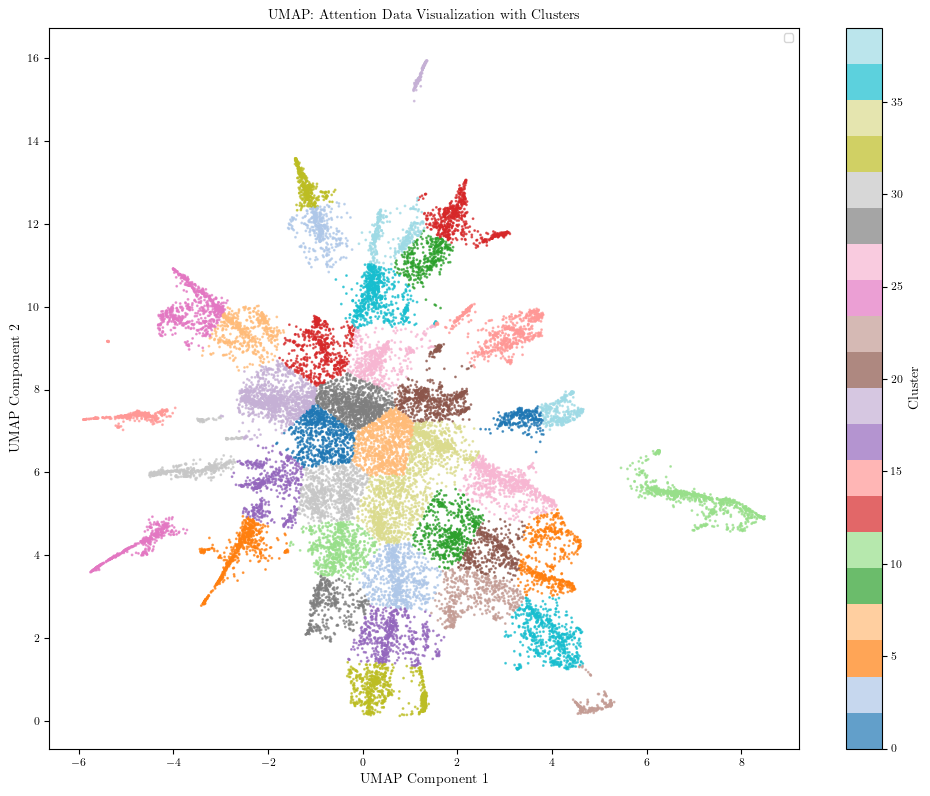

In [9]:

# Plot UMAP results with cluster colors
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(umap_result[:, 0], umap_result[:, 1], 
                     c=cluster_labels, cmap='tab20', 
                     alpha=0.7, s=1)

# Add colorbar to show cluster labels
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster')

# Add markers for checkmate puzzles
#ax.scatter(umap_result[checkmate_mask, 0], umap_result[checkmate_mask, 1], 
#           facecolors='none', edgecolors='red', s=5, label='Checkmate')

ax.set_xlabel('UMAP Component 1')
ax.set_ylabel('UMAP Component 2')
ax.set_title(f'UMAP: Attention Data Visualization with Clusters')
ax.legend()

plt.tight_layout()
plt.show()

# Function to get puzzles in a specific cluster
def get_puzzles_in_cluster(cluster_id):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    return study.puzzles.iloc[cluster_indices]

# Calculate the center of each cluster
# cluster_centers = kmeans.cluster_centers_

In [26]:
def plot_attention_grid(puzzles, n_cols=4, vmax=0.5, filename=None):
    n_plots = len(puzzles)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 3*n_rows), sharex=True, sharey=True)

    n_layers, n_heads = 15, 24
    data = np.full((n_heads, n_layers), '', dtype=object)

    for layer, head in knight_heads:
        data[head, layer] = 'K'
    for layer, head in bishop_heads:
        data[head, layer] = 'B'
    for layer, head in rook_heads:
        data[head, layer] = 'R'

    for idx, (ind, puzzle) in enumerate(puzzles.iterrows()):
        row, col = divmod(idx, n_cols)

        pos = study.puzzles.index.get_loc(ind)
        print(idx, ind, pos)
        effects = study.all_attentions[pos, :, :]

        ax = axes[row, col] if n_rows > 1 else axes[col]
        try:
            sns.heatmap(effects.T, cmap=fh.EFFECTS_CMAP_2, ax=ax, cbar=False, vmin=0, vmax=vmax)
            ax.set_title(f"{puzzle['PuzzleId']}")
            for i in range(n_heads):
                for j in range(n_layers):
                    if data[i, j]:
                        text_color = {'K': 'blue', 'B': 'green', 'R': 'red'}[data[i, j]]
                        ax.text(j+0.5, i+0.5, data[i, j], ha='center', va='center', color=text_color, fontsize='xx-small')
            if col == 0:
                ax.set_ylabel("Head")
            if row == n_rows - 1:
                ax.set_xlabel("Layer")
        except ValueError:
            ax.axis('off')

    for idx in range(n_plots, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        if n_rows > 1:
            axes[row, col].axis('off')
        else:
            axes[col].axis('off')

    plt.tight_layout()
    plt.show()

In [33]:
example_puzzles = get_puzzles_in_cluster(23)
example_puzzles.shape

(175, 19)

In [ ]:
plot_attention_grid(example_puzzles.iloc[:48], n_cols=8, vmax=0.5)

In [30]:
example_puzzles

,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags,principal_variation,full_pv_probs,full_model_moves,full_wdl,sparring_full_pv_probs,sparring_full_model_moves,sparring_wdl,different_targets,corrupted_fen
9265,09SS5,r5k1/4Qpp1/6P1/3p4/2q5/p3R3/5P2/6K1 b - - 0 32,d5d4 e7e8 a8e8 e3e8,1466,77,93,6963,endgame mate mateIn2 sacrifice short,https://lichess.org/nzEg5nBY/black#63,NaN,"[e7e8, a8e8, e3e8]","[0.6017847061157227, 1.0, 0.9276193380355835]","[e7e8, a8e8, e3e8]","[0.591432511806488, 0.37828412652015686, 0.030...","[0.013065310195088387, 1.0, 0.3194984793663025]","[e3a3, a8e8, e3e8]","[0.004359008744359016, 0.9926069974899292, 0.0...",False,r5k1/4Qpp1/8/8/2qp4/p3R3/5P2/6K1 w - - 0 33
19507,0K3hv,r4rk1/pp5p/3q4/3P4/2R3pP/P1Q2pK1/1P3N2/5R2 w -...,g3g4 d6g6 g4h3 g6g2,1398,75,96,8377,mate mateIn2 middlegame short,https://lichess.org/WMZ9c77r#64,NaN,"[d6g6, g4h3, g6g2]","[0.6514212489128113, 1.0, 0.9141947627067566]","[d6g6, g4h3, g6g2]","[0.6293396353721619, 0.2610663175582886, 0.109...","[0.0495099313557148, 1.0, 0.6070330739021301]","[h7h5, g4h3, g6g2]","[0.0014258386800065637, 0.9936625957489014, 0....",True,r4rk1/pp5p/3q4/3P4/2R3KP/P1Q5/1P3N2/5R2 b - - ...
30390,0VEYH,3r4/p2rk3/1p2p2p/5p2/2PPKP1P/1P6/3R4/3R4 w - -...,e4e5 d7d5 c4d5 d8d5,1613,76,99,686,endgame mate mateIn2 rookEndgame sacrifice short,https://lichess.org/rR7Bl7s7#66,NaN,"[d7d5, c4d5, d8d5]","[0.8190457224845886, 1.0, 0.934782862663269]","[d7d5, c4d5, d8d5]","[0.8836283087730408, 0.11059670895338058, 0.00...","[0.016093265265226364, 1.0, 0.7861309051513672]","[e7f7, c4d5, d8d5]","[0.005844333209097385, 0.9840615391731262, 0.0...",False,3r4/p2rk3/1p5p/4Kp2/2PP1P1P/1P6/3R4/3R4 b - - ...
33819,0YkU9,8/8/pp1pQk1p/2p2p2/P4Nq1/8/1P3K1P/8 b - - 5 42,f6g5 e6e7 g5f4 e7e3,2259,111,48,61,endgame master mate mateIn2 sacrifice short,https://lichess.org/UufP4nap/black#83,NaN,"[e6e7, g5f4, e7e3]","[0.5567064881324768, 1.0, 0.909664511680603]","[e6e7, g5f4, e7e3]","[0.8560073375701904, 0.1373535394668579, 0.006...","[0.019415486603975296, 1.0, 0.27774450182914734]","[e6d6, g5f4, e7d6]","[0.18271104991436005, 0.7961007356643677, 0.02...",True,8/8/pp1pQ2p/2p2pk1/P4Nq1/8/1P5P/7K w - - 6 43
47506,0mv4f,6k1/1r4p1/5b1p/3p1B1P/p1r2P2/P1P5/1PK5/3RR3 b ...,c4f4 e1e8 g8f7 f5g6,1422,75,94,488,endgame mate mateIn2 short,https://lichess.org/DEwJzYOB/black#63,NaN,"[e1e8, g8f7, f5g6]","[0.5418182611465454, 1.0, 0.9121462106704712]","[e1e8, g8f7, f5g6]","[0.7878837585449219, 0.20302414894104004, 0.00...","[0.04822345823049545, 1.0, 0.942719042301178]","[f5g6, g8f7, f5g6]","[0.3456690013408661, 0.6182215213775635, 0.036...",True,6k1/1r4p1/5b1p/3p1B2/p4r2/P1P5/1PK5/3RR3 w - -...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983352,GBxYV,8/1p1k4/2p3p1/1pK3P1/1P1P4/P1P5/8/8 w - - 2 43,c3c4 b7b6 c5b6 b5c4 a3a4 c4c3,1794,80,87,54,crushing deflection endgame long pawnEndgame,https://lichess.org/oWMNbMC6#84,NaN,"[b7b6, c5b6, b5c4, a3a4, c4c3]","[0.899716854095459, 1.0, 0.9815446138381958, 0...","[b7b6, c5b6, b5c4, a3a4, c4c3]","[0.08190897107124329, 0.6221648454666138, 0.29...","[0.0431511327624321, 1.0, 0.4187610447406769, ...","[b5c4, c5b6, b5c4, b4b5, c4c3]","[0.013236439786851406, 0.8684672713279724, 0.1...",False,8/1p1k4/6p1/1pK3P1/1PPP4/P7/8/8 b - - 0 43
989025,GHjKx,2b2r2/5p1k/3QpPpp/1pp2q2/8/3R4/rP3PPP/5RK1 b -...,h7g8 d6f8 g8f8 d3d8,1059,78,90,1293,attraction kingsideAttack mate mateIn2 middleg...,https://lichess.org/v2kMFMle/black#45,NaN,"[d6f8, g8f8, d3d8]","[0.8440947532653809, 0.5747814178466797, 0.893...","[d6f8, g8f8, d3d8]","[0.7049635648727417, 0.13946932554244995, 0.15...","[0.03867039829492569, 0.8758082389831543, 0.59...","[d3f3, g8f8, d3d8]","[0.002880108542740345, 0.982111394405365, 0.01...",False,2b2rk1/5p2/3Qp1pp/1pp2q2/8/3R4/rP3PPP/5RK1 w -...
992560,GLM0T,r1b2r1k/1pB3bP/p4p2/3Q4/2n1n1q1/1B3N2/PPP3PP/R...,c4e3 d5g8 f8g8 h7g8q,1456,168,0,20,advancedPawn kingsideAttack mate mateIn2 middl...,https://lichess.or

In [ ]:
# Create a mask for checkmate puzzles
checkmate_mask = study.puzzles["Themes"].apply(lambda x: "mateIn3" in x)
checkmate_mask = checkmate_mask & study.puzzles.principal_variation.apply(lambda x: len(x) == 5)
checkmate_mask = checkmate_mask.values

# Reshape the tensor to 2D
attentions_2d = study.all_attentions[checkmate_mask, 10:, :].reshape(len(study.all_attentions[checkmate_mask]), -1)

# Convert to numpy array
attentions_np = attentions_2d.cpu().numpy()

# Apply t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(attentions_np)

# Print the shape of the t-SNE result
print("t-SNE result shape:", tsne_result.shape)

# Apply KMeans clustering
from sklearn.cluster import KMeans
n_clusters = 20 # You can adjust this number
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(tsne_result)

# Plot t-SNE results with cluster colors
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1], 
                     c=cluster_labels, cmap='tab20', 
                     alpha=0.7, s=5)

# Add colorbar to show cluster labels
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster')

# Add markers for checkmate puzzles
# ax.scatter(tsne_result[checkmate_mask, 0], tsne_result[checkmate_mask, 1], 
#            facecolors='none', edgecolors='red', s=20, label='Checkmate')

ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_title(f't-SNE: Attention Data Visualization with Clusters')
#ax.legend()

plt.tight_layout()
plt.show()

# Function to get puzzles in a specific cluster
def get_puzzles_in_cluster(cluster_id):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    return study.puzzles.iloc[cluster_indices]

# Calculate the center of each cluster
# cluster_centers = kmeans.cluster_centers_

In [64]:
get_puzzles_in_cluster(13)

,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags,principal_variation,full_pv_probs,full_model_moves,full_wdl,sparring_full_pv_probs,sparring_full_model_moves,sparring_wdl,different_targets,corrupted_fen
2263,02IqG,r2r2k1/p4pn1/4pBp1/1p6/3P1Q1R/2q4P/6P1/6K1 b -...,d8d5 h4h8 g8h8 f4h6 h8g8 h6g7,1779,76,86,275,attraction long mate mateIn3 middlegame sacrifice,https://lichess.org/BfFqbEze/black#69,NaN,"[h4h8, g8h8, f4h6, h8g8, h6g7]","[0.614358127117157, 1.0, 0.8896070122718811, 1...","[h4h8, g8h8, f4h6, h8g8, h6g7]","[0.4905891716480255, 0.3809987008571625, 0.128...","[0.0322921946644783, 1.0, 0.4838876724243164, ...","[f4h6, g8h8, f4h6, h8g8, h6g7]","[0.0026868595741689205, 0.9921988844871521, 0....",False,r4qk1/p4pn1/4pBp1/1p1r4/3P1Q1R/7P/6P1/6K1 w - ...
2665,02j28,8/3nk1r1/7q/p1pPpQ1P/PpP3P1/1P3R2/5P2/6K1 b - ...,h6f6 f5d7 e7d7 f3f6,1658,75,92,3064,crushing discoveredAttack endgame short,https://lichess.org/rcSTVh6s/black#85,NaN,"[f5d7, e7d7, f3f6]","[0.661375105381012, 0.9402832388877869, 0.9657...","[f5d7, e7d7, f3f6]","[0.6449331641197205, 0.3193162977695465, 0.035...","[0.00441362988203764, 0.9760007262229919, 0.82...","[g1f1, e7d7, f3f6]","[0.021578552201390266, 0.9558650851249695, 0.0...",False,8/3n2r1/5q2/p1pPpQ1P/PpP3P1/1P3R2/1k3P2/6K1 w ...
3389,03Qdr,r6r/1p1kbpp1/6p1/p1pp4/6P1/P2P3P/1PP2PK1/R1B1R...,h8h4 e1e7 d7e7 c1g5 e7d7 g5h4,1144,77,98,5524,attraction crushing endgame exposedKing fork l...,https://lichess.org/0saEK0Bh/black#37,Scandinavian_Defense Scandinavian_Defense_Othe...,"[e1e7, d7e7, c1g5, e7d7, g5h4]","[0.8465999364852905, 0.834049642086029, 0.9602...","[e1e7, d7e7, c1g5, f7f6, g5h4]","[0.8653011918067932, 0.11375441402196884, 0.02...","[0.0010531407315284014, 0.9229974746704102, 0....","[a3a4, d7e7, c1g5, e7d7, g5h4]","[0.02863786369562149, 0.9492778778076172, 0.02...",False,r7/1p1kbppr/6p1/p1pp4/6P1/P2P3P/1PP2PK1/R1B1R3...
3730,03nT3,r5kr/p1pQ2b1/1p2pq2/8/3N1B2/3B4/PPP2P1P/R3K3 b...,f6f4 d7g7 g8g7 d4e6 g7f6 e6f4,2241,97,79,22,advantage attraction exposedKing fork long mid...,https://lichess.org/9GCZlyx8/black#31,Owen_Defense Owen_Defense_Matovinsky_Gambit,"[d7g7, g8g7, d4e6, g7f6, e6f4]","[0.572193443775177, 1.0, 0.9288406372070312, 0...","[d7g7, g8g7, d4e6, g7f6, e6f4]","[0.6244988441467285, 0.3254060745239258, 0.050...","[0.0011580252321437001, 1.0, 0.248477369546890...","[d7e6, g8g7, d4e6, g7f6, e6f4]","[0.02825998142361641, 0.964590311050415, 0.007...",False,r5kr/p1pQ2b1/1p2p3/6p1/3N1q2/3B4/PPP2P1P/R3K3 ...
4661,04m4i,6k1/Q1R2r2/5n1p/3p1p1q/P2P1B2/4PnPP/1r4B1/R6K ...,c7f7 h5h3 g2h3 b2h2,1770,74,92,7071,arabianMate mate mateIn2 middlegame sacrifice ...,https://lichess.org/4HpeVvsd#64,NaN,"[h5h3, g2h3, b2h2]","[0.826633632183075, 1.0, 0.870471715927124]","[h5h3, g2h3, b2h2]","[0.7771250605583191, 0.17236824333667755, 0.05...","[0.029008906334638596, 1.0, 0.692120373249054]","[b2g2, g2h3, b2h2]","[0.0015076795825734735, 0.9952736496925354, 0....",False,6k1/Q4R2/5n1p/3p1p1q/P2P1B2/4Pn1P/1r4B1/R6K b ...
5678,05pYG,r1b2k1r/pp1p1p1p/6pb/8/N1PB4/P7/1PKn2PP/4RR2 b...,h6g7 d4c5 d7d6 c5d6 f8g8 e1e8,2160,74,94,1553,crushing long middlegame,https://lichess.org/ZYeKq1GF/black#43,NaN,"[d4c5, d7d6, c5d6, f8g8, e1e8]","[0.670608401298523, 0.7404603362083435, 0.9105...","[d4c5, d7d6, c5d6, f8g8, e1e8]","[0.4432261884212494, 0.40416833758354187, 0.15...","[0.04979148879647255, 0.9422144889831543, 0.46...","[c2d2, d7d6, c5d6, f8g8, c2d2]","[0.002616026671603322, 0.9919379353523254, 0.0...",False,2b2k1r/pprp1pbp/6p1/8/N1PB4/P7/1PKn2PP/4RR2 w ...
9172,09Npd,8/2k5/2P3p1/pP1Kp1P1/P2b1p2/5P2/8/8 b - - 0 58,d4a1 b5b6 c7b6 d5d6 e5e4 c6c7 a1e5 d6e5 b6c7 e5e4,2199,74,94,9421,advancedPawn bishopEndgame crushing endgame ve...,https://lichess.org/ytOuIXVO/black#115,NaN,"[b5b6, c7b6, d5d6, e5e4, c6c7, a1e5, d6e5, b6c...","[0.5441432595252991, 0.26771432161331177, 0.97...","[b5b6, c7c8, d5d6, e5e4, c6c7, a1e5, d6e5, b6c...","[0.05827036127448082, 0.3086443841457367, 0.63...","[0.044175807386636

In [ ]:
# Reshape the tensor to 2D
N = 22517
attentions_2d = study.all_attentions[:N, :, :].reshape(N, -1)

# Convert to numpy array
attentions_np = attentions_2d.cpu().numpy()

# Apply t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(attentions_np)

# Print the shape of the t-SNE result
print("t-SNE result shape:", tsne_result.shape)

# Create a mask for checkmate puzzles
checkmate_mask = study.puzzles.iloc[:N]["Themes"].apply(lambda x: "mateIn2" in x).values

# Apply KMeans clustering
from sklearn.cluster import KMeans
n_clusters = 40 # You can adjust this number
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(tsne_result)

# Plot t-SNE results with cluster colors
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1], 
                     c=cluster_labels, cmap='tab20', 
                     alpha=0.7, s=5)

# Add colorbar to show cluster labels
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster')

# Add markers for checkmate puzzles
ax.scatter(tsne_result[checkmate_mask, 0], tsne_result[checkmate_mask, 1], 
           facecolors='none', edgecolors='red', s=20, label='Checkmate')

ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_title(f't-SNE: Attention Data Visualization with Clusters')
ax.legend()

plt.tight_layout()
plt.show()

# Function to get puzzles in a specific cluster
def get_puzzles_in_cluster(cluster_id):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    return study.puzzles.iloc[cluster_indices]

# Calculate the center of each cluster
# cluster_centers = kmeans.cluster_centers_

In [33]:
checkmate_mask = study.puzzles.iloc[:N]["Themes"].apply(lambda x: "mateIn5" in x).values
#checkmate_mask = checkmate_mask & study.puzzles.iloc[:N].principal_variation.apply(lambda x: len(x) == 7)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1], 
                     c=cluster_labels, cmap='tab20', 
                     alpha=0.7, s=1)

# Add colorbar to show cluster labels
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster')

# Add markers for checkmate puzzles
ax.scatter(tsne_result[checkmate_mask, 0], tsne_result[checkmate_mask, 1], 
           facecolors='none', edgecolors='red', s=5, label='Checkmate')

ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_title(f't-SNE: Attention Data Visualization with Clusters')
ax.legend()

plt.tight_layout()
plt.show()

In [31]:
cluster_centers = kmeans.cluster_centers_

In [36]:
cluster_centers[26:28]

array([[-29.72949 ,  23.35608 ],
       [-55.38313 ,  34.798046]], dtype=float32)

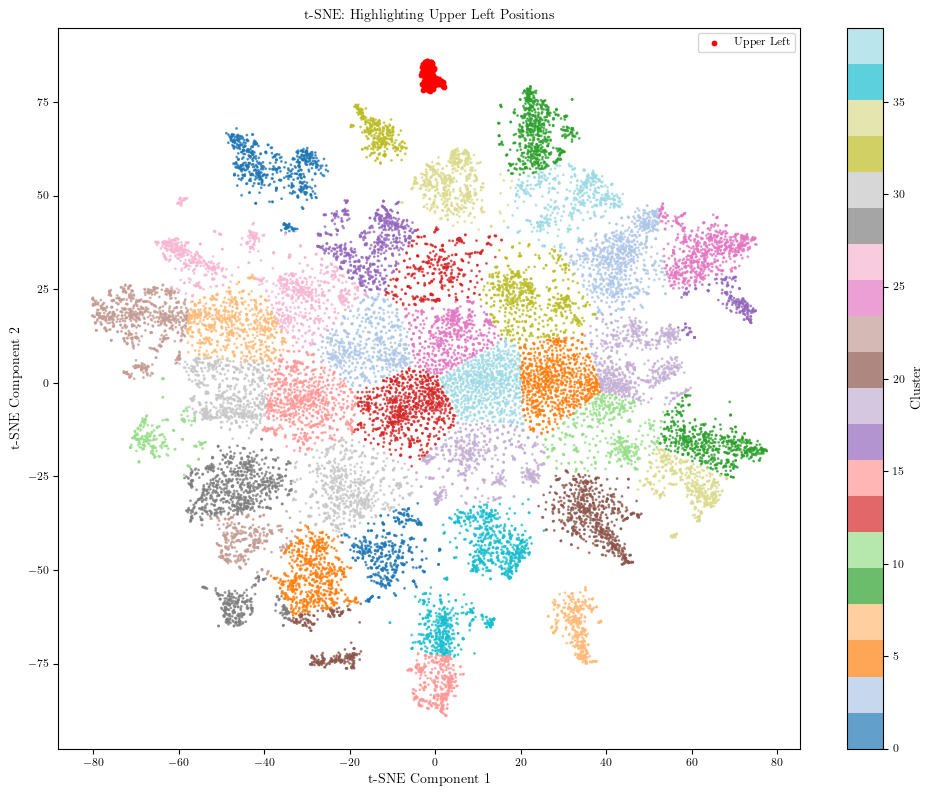

Number of positions in the upper left: 140

Sample of positions in the upper left:
Index: 215, PuzzleId: 09SS5, FEN: r5k1/4Qpp1/6P1/3p4/2q5/p3R3/5P2/6K1 b - - 0 32
Index: 480, PuzzleId: 0K3hv, FEN: r4rk1/pp5p/3q4/3P4/2R3pP/P1Q2pK1/1P3N2/5R2 w - - 1 33
Index: 748, PuzzleId: 0VEYH, FEN: 3r4/p2rk3/1p2p2p/5p2/2PPKP1P/1P6/3R4/3R4 w - - 0 34
Index: 1160, PuzzleId: 0mv4f, FEN: 6k1/1r4p1/5b1p/3p1B1P/p1r2P2/P1P5/1PK5/3RR3 b - - 2 32
Index: 1232, PuzzleId: 0rH7J, FEN: 8/5p2/5Rp1/Pp5p/3K1k2/1r5P/6P1/8 b - - 1 40


In [50]:
upper_left_mask = (tsne_result[:, 0] < 10) & (tsne_result[:, 1] > 75)

# Plot the t-SNE results again, highlighting the upper left positions
fig, ax = plt.subplots(figsize=(10, 8))

# Plot all points
scatter = ax.scatter(tsne_result[:, 0], tsne_result[:, 1], 
                     c=cluster_labels, cmap='tab20', 
                     alpha=0.7, s=1)

# Highlight upper left positions
ax.scatter(tsne_result[upper_left_mask, 0], tsne_result[upper_left_mask, 1], 
           color='red', s=10, label='Upper Left')

# Add colorbar to show cluster labels
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster')

ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_title('t-SNE: Highlighting Upper Left Positions')
ax.legend()

plt.tight_layout()
plt.show()

# Print the number of positions in the upper left
print(f"Number of positions in the upper left: {np.sum(upper_left_mask)}")

# Get the indices of the upper left positions
upper_left_indices = np.where(upper_left_mask)[0]

# Print some information about these positions
print("\nSample of positions in the upper left:")
for idx in upper_left_indices[:5]:  # Print first 5 as a sample
    puzzle = study.puzzles.iloc[idx]
    print(f"Index: {idx}, PuzzleId: {puzzle['PuzzleId']}, FEN: {puzzle['FEN']}")


In [53]:
example_puzzles = study.puzzles.iloc[upper_left_indices]

# Only keep FEN, Rating, Themes, principal_variation columns
example_puzzles = example_puzzles[['FEN', 'Rating', 'Themes', 'principal_variation']]

# Display all example puzzles
print(example_puzzles)

# Get the number of example puzzles
num_puzzles = len(example_puzzles)
print(f"\nTotal number of example puzzles: {num_puzzles}")

# Display some statistics about the ratings
print("\nRating statistics:")
print(example_puzzles['Rating'].describe())

# Count the occurrences of each theme
theme_counts = example_puzzles['Themes'].str.split().explode().value_counts()
print("\nTop 10 most common themes:")
print(theme_counts.head(10))

# Display a few example boards
print("\nDisplaying 3 example boards:")
for i in range(min(3, num_puzzles)):
    puzzle = example_puzzles.iloc[i]
    print(f"\nPuzzle {i+1}:")
    print(f"FEN: {puzzle['FEN']}")
    print(f"Rating: {puzzle['Rating']}")
    print(f"Themes: {puzzle['Themes']}")
    print(f"Principal Variation: {puzzle['principal_variation']}")
    print(LeelaBoard.from_fen(puzzle['FEN']))


                                                      FEN  Rating  \
9265       r5k1/4Qpp1/6P1/3p4/2q5/p3R3/5P2/6K1 b - - 0 32    1466   
19507   r4rk1/pp5p/3q4/3P4/2R3pP/P1Q2pK1/1P3N2/5R2 w -...    1398   
30390   3r4/p2rk3/1p2p2p/5p2/2PPKP1P/1P6/3R4/3R4 w - -...    1613   
47506   6k1/1r4p1/5b1p/3p1B1P/p1r2P2/P1P5/1PK5/3RR3 b ...    1422   
51819         8/5p2/5Rp1/Pp5p/3K1k2/1r5P/6P1/8 b - - 1 40    1674   
...                                                   ...     ...   
983352     8/1p1k4/2p3p1/1pK3P1/1P1P4/P1P5/8/8 w - - 2 43    1794   
989025  2b2r2/5p1k/3QpPpp/1pp2q2/8/3R4/rP3PPP/5RK1 b -...    1059   
992560  r1b2r1k/1pB3bP/p4p2/3Q4/2n1n1q1/1B3N2/PPP3PP/R...    1456   
995461  1k1r4/p3b3/Pp1q3p/4p1p1/4P1n1/4B1PB/2Q2P1P/2R3...     917   
999356  5rk1/pp6/3p2q1/2p1p3/1PP1Pp2/P1R2P1p/6rP/3QBR1...    1312   

                                                   Themes  \
9265                 endgame mate mateIn2 sacrifice short   
19507                       mate mateIn2 middlega

In [55]:
import pandas as pd

In [56]:
# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Display all rows and columns from example_puzzles
print(example_puzzles.to_string())

# Reset display options to default
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')


                                                                        FEN  Rating                                                                               Themes                                     principal_variation
9265                         r5k1/4Qpp1/6P1/3p4/2q5/p3R3/5P2/6K1 b - - 0 32    1466                                                 endgame mate mateIn2 sacrifice short                                      [e7e8, a8e8, e3e8]
19507                 r4rk1/pp5p/3q4/3P4/2R3pP/P1Q2pK1/1P3N2/5R2 w - - 1 33    1398                                                        mate mateIn2 middlegame short                                      [d6g6, g4h3, g6g2]
30390                   3r4/p2rk3/1p2p2p/5p2/2PPKP1P/1P6/3R4/3R4 w - - 0 34    1613                                     endgame mate mateIn2 rookEndgame sacrifice short                                      [d7d5, c4d5, d8d5]
47506                6k1/1r4p1/5b1p/3p1B1P/p1r2P2/P1P5/1PK5/3RR3 b - - 2 32    1422                 

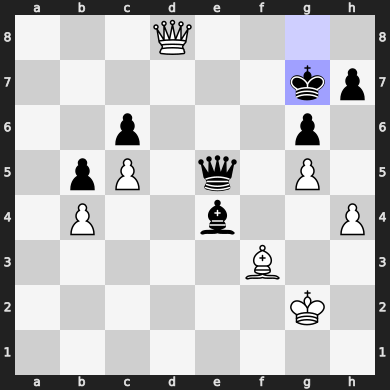

In [49]:
LeelaBoard.from_puzzle(study.puzzles.iloc[upper_left_indices].iloc[0])

In [37]:
get_puzzles_in_cluster(27)

,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags,principal_variation,full_pv_probs,full_model_moves,full_wdl,sparring_full_pv_probs,sparring_full_model_moves,sparring_wdl,different_targets,corrupted_fen
8981,09BED,6k1/5pp1/pq5p/4p3/P1r1B3/5Q2/5PPP/3R2K1 w - - ...,d1b1 b6b1 e4b1 c4c1 f3d1 c1d1,728,77,100,256,backRankMate endgame fork long mate mateIn3 sa...,https://lichess.org/HBItIvT7#52,NaN,"[b6b1, e4b1, c4c1, f3d1, c1d1]","[0.6018850207328796, 0.5390170216560364, 0.947...","[b6b1, e4b1, c4c1, f3d1, c1d1]","[0.20781713724136353, 0.14785797894001007, 0.6...","[0.03383659943938255, 0.945868194103241, 0.777...","[b6b2, e4b1, c4c1, f3d1, c1d1]","[0.012928920798003674, 0.912183403968811, 0.07...",False,6k1/5pp1/pq5p/4p3/P1r1B3/5Q2/5PPP/1R3K2 b - - ...
10107,0ALUW,r3k2r/pp1nqpp1/2p1p3/8/1b1PQB1P/8/PPP5/2KR1B1R...,e8c8 e4c6 b7c6 f1a6,1654,79,91,1814,bodenMate mate mateIn2 middlegame queensideAtt...,https://lichess.org/qlIC64I0/black#35,Rapport-Jobava_System Rapport-Jobava_System_Ot...,"[e4c6, b7c6, f1a6]","[0.6122609972953796, 1.0, 0.851652979850769]","[e4c6, b7c6, f1a6]","[0.5888730883598328, 0.31699052453041077, 0.09...","[0.0026452792808413506, 1.0, 0.44557347893714905]","[a2a3, b7c6, f1a6]","[0.016077840700745583, 0.9450819492340088, 0.0...",False,2k1r2r/pp1nqpp1/2p1p3/8/1b1PQB1P/8/PPP5/2KR1B1...
10269,0AVRV,4rr2/6pk/1R6/p1PQ4/P5p1/8/5qPP/1R5K w - - 4 36,b1g1 f2g1 h1g1 e8e1,1764,78,84,158,attraction endgame mate mateIn2 sacrifice short,https://lichess.org/uesdO3xC#70,NaN,"[f2g1, h1g1, e8e1]","[0.5489198565483093, 1.0, 0.9291157722473145]","[f2g1, h1g1, e8e1]","[0.8493800163269043, 0.14689651131629944, 0.00...","[0.013089567422866821, 1.0, 0.668947160243988]","[f8f5, h1g1, e8e1]","[0.00893634557723999, 0.9721528887748718, 0.01...",False,4rr2/6pk/1R6/p1PQ4/P5p1/8/4PqPP/6RK b - - 5 36
14488,0EsSZ,2k5/ppp1np1r/2p2B1p/2b5/4P3/2N2P1q/PPP1KP2/3R2...,h3h2 g1g8 e7g8 d1d8,1401,82,88,54,mate mateIn2 middlegame sacrifice short,https://lichess.org/hQtd9Arj/black#31,Ruy_Lopez Ruy_Lopez_Other_variations,"[g1g8, e7g8, d1d8]","[0.8819349408149719, 1.0, 0.7828513979911804]","[g1g8, e7g8, d1d8]","[0.6728500127792358, 0.1740751415491104, 0.153...","[0.004683501087129116, 1.0, 0.342070072889328]","[e2e1, e7g8, d1d8]","[0.003564954735338688, 0.9885923266410828, 0.0...",False,2k5/p1p1np1r/2p2B1p/2b5/4P3/2N2P2/PPP1KP1q/3R2...
16238,0GiIY,rnkr4/pp2bppp/2p1p3/8/R2P1B2/1P1B1P2/1P3PPP/2R...,b8d7 c1c6 b7c6 d3a6,1091,98,72,3154,bodenMate mate mateIn2 middlegame queensideAtt...,https://lichess.org/DjMM2PDH/black#29,Slav_Defense Slav_Defense_Three_Knights_Variation,"[c1c6, b7c6, d3a6]","[0.7404528260231018, 1.0, 0.8536109328269958]","[c1c6, b7c6, d3a6]","[0.5687335133552551, 0.29083335399627686, 0.14...","[0.01277477853000164, 1.0, 0.6997327208518982]","[d4d5, b7c6, d3a6]","[0.010112715885043144, 0.9689901471138, 0.0208...",False,r1kr4/pp1nbppp/2ppp3/8/R2P1B2/1P1B1P2/1P3PPP/2...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
982446,GB29o,5rrk/R1R3p1/1p2p2p/4Np1Q/5q2/P6P/6P1/7K b - - ...,f4e5 h5h6 g7h6 c7h7,1478,75,82,133,endgame mate mateIn2 sacrifice short,https://lichess.org/FyudUlL1/black#81,NaN,"[h5h6, g7h6, c7h7]","[0.8637920618057251, 1.0, 0.8688674569129944]","[h5h6, g7h6, c7h7]","[0.49696752429008484, 0.44124725461006165, 0.0...","[0.033852946013212204, 1.0, 0.8112079501152039]","[h5h4, g7h6, c7h7]","[0.008576820604503155, 0.9147619009017944, 0.0...",False,1r3r1k/R1R3p1/1p2p2p/4qp1Q/8/P6P/6P1/7K w - - ...
982516,GB6pK,5rk1/5ppp/R1N1p3/1P6/2P3K1/Q4nP1/7q/8 b - - 1 43,f3g1 a3f8 g8f8 a6a8,1655,74,95,10297,attraction endgame mate mateIn2 sacrifice short,https://lichess.org/biHTEuDQ/black#85,NaN,"[a3f8, g8f8, a6a8]","[0.5040013194084167, 1.0, 0.941574215888977]","[a3f8, g8f8, a6a8]","[0.3899659812450409, 0.33358410000801086, 0.27...","[0.017052531242370605, 1.0, 0.8079063296318054]","[c6e7, g8f8, a6a8]","[0.004833501763641834, 0.9690690040588379, 0.0...",False,5rk1/p4ppp/R1N1p3/1P6/2P3

In [45]:
boards = [LeelaBoard.from_puzzle(puzzle) for _, puzzle in study.puzzles.iloc[:1000].iterrows()]
with model.trace(boards):
    act_array = [model.residual_stream(layer).output.save() for layer in range(15)]

In [46]:
act_values = [act.value for act in act_array]

In [ ]:
# Apply PCA to study.all_attentions
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

for i in range(15):

    # Reshape the tensor to 2D
    attentions_2d = act_values[i].reshape(len(boards), -1)

    # Convert to numpy array
    attentions_np = attentions_2d.cpu().numpy()

    # Apply PCA
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(attentions_np)

    # Print the shape of the PCA result
    print("PCA result shape:", pca_result.shape)

    # Print the explained variance ratio
    print("Explained variance ratio:", pca.explained_variance_ratio_)

    # Create a mask for checkmate puzzles
    checkmate_mask = study.puzzles.iloc[:len(boards)]["Themes"].apply(lambda x: "mateIn2" in x).values
    #checkmate_mask_1 = study.puzzles.iloc[:len(boards)].principal_variation.apply(lambda x: len(x) == 3).values
    #checkmate_mask_2 = study.puzzles.iloc[:len(boards)].principal_variation.apply(lambda x: x[0][2:4] == x[1][2:4] == x[2][2:4]).values
    #checkmate_mask = checkmate_mask_1 & checkmate_mask_2

    # Plot PC1 vs PC2
    fig, ax = plt.subplots(figsize=(5, 4))
    scatter_checkmate = ax.scatter(pca_result[checkmate_mask, 0], pca_result[checkmate_mask, 1], 
                                alpha=0.5, c='red', label='Checkmate', s=3)
    scatter_non_checkmate = ax.scatter(pca_result[~checkmate_mask, 0], pca_result[~checkmate_mask, 1], 
                                    alpha=0.5, c='blue', label='Non-checkmate', s=3)

    ax.set_xlabel('First Principal Component')
    ax.set_ylabel('Second Principal Component')
    ax.set_title(f'PCA: PC1 vs PC2 for Attention Data, Layer {i}')
    ax.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
# Apply t-SNE to study.all_attentions
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

for i in range(15):

    # Reshape the tensor to 2D
    attentions_2d = act_values[i].reshape(len(boards), -1)

    # Convert to numpy array
    attentions_np = attentions_2d.cpu().numpy()

    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(attentions_np)

    # Print the shape of the t-SNE result
    print("t-SNE result shape:", tsne_result.shape)

    # Create a mask for checkmate puzzles
    checkmate_mask = study.puzzles.iloc[:len(boards)]["Themes"].apply(lambda x: "mateIn2" in x).values

    # Plot t-SNE results
    fig, ax = plt.subplots(figsize=(5, 4))
    scatter_checkmate = ax.scatter(tsne_result[checkmate_mask, 0], tsne_result[checkmate_mask, 1], 
                                alpha=0.5, c='red', label='Checkmate', s=3)
    scatter_non_checkmate = ax.scatter(tsne_result[~checkmate_mask, 0], tsne_result[~checkmate_mask, 1], 
                                    alpha=0.5, c='blue', label='Non-checkmate', s=3)

    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    ax.set_title(f't-SNE: Attention Data Visualization, Layer {i}')
    ax.legend()

    plt.tight_layout()
    plt.show()

# Uncomment the following block to use UMAP instead of t-SNE
'''
# Apply UMAP to study.all_attentions
from umap import UMAP

for i in range(15):

    # Reshape the tensor to 2D
    attentions_2d = act_values[i].reshape(len(boards), -1)

    # Convert to numpy array
    attentions_np = attentions_2d.cpu().numpy()

    # Apply UMAP
    umap = UMAP(n_components=2, random_state=42)
    umap_result = umap.fit_transform(attentions_np)

    # Print the shape of the UMAP result
    print("UMAP result shape:", umap_result.shape)

    # Create a mask for checkmate puzzles
    checkmate_mask = study.puzzles.iloc[:len(boards)]["Themes"].apply(lambda x: "mateIn2" in x).values

    # Plot UMAP results
    fig, ax = plt.subplots(figsize=(5, 4))
    scatter_checkmate = ax.scatter(umap_result[checkmate_mask, 0], umap_result[checkmate_mask, 1], 
                                alpha=0.5, c='red', label='Checkmate', s=3)
    scatter_non_checkmate = ax.scatter(umap_result[~checkmate_mask, 0], umap_result[~checkmate_mask, 1], 
                                    alpha=0.5, c='blue', label='Non-checkmate', s=3)

    ax.set_xlabel('UMAP Component 1')
    ax.set_ylabel('UMAP Component 2')
    ax.set_title(f'UMAP: Attention Data Visualization, Layer {i}')
    ax.legend()

    plt.tight_layout()
    plt.show()
'''

UMAP result shape: (1000, 2)


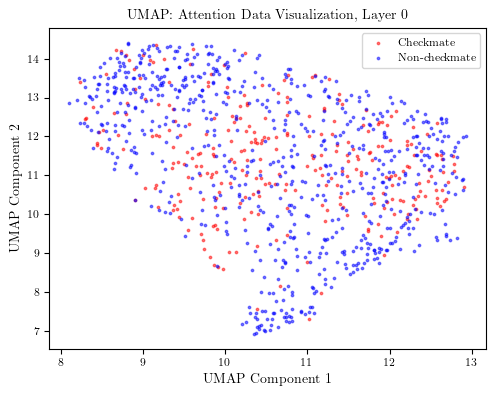

UMAP result shape: (1000, 2)


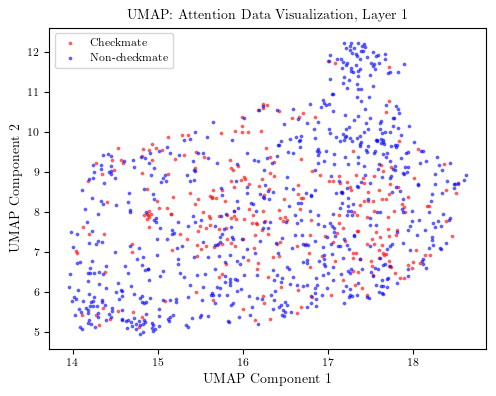

UMAP result shape: (1000, 2)


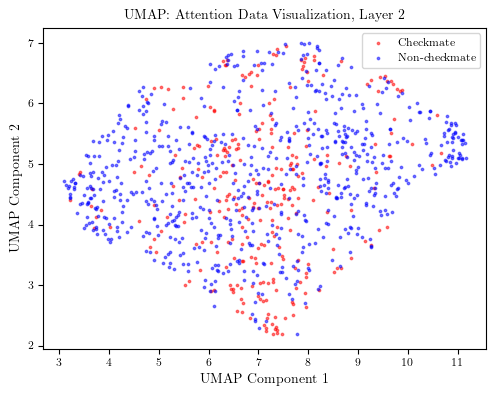

UMAP result shape: (1000, 2)


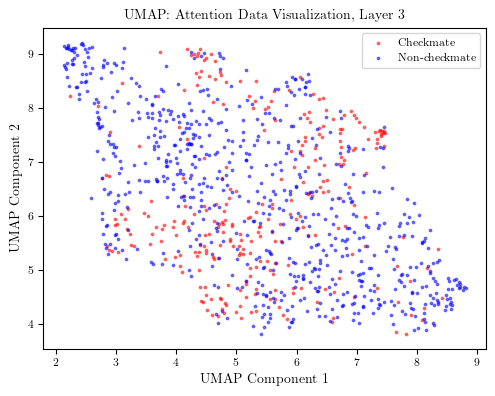

UMAP result shape: (1000, 2)


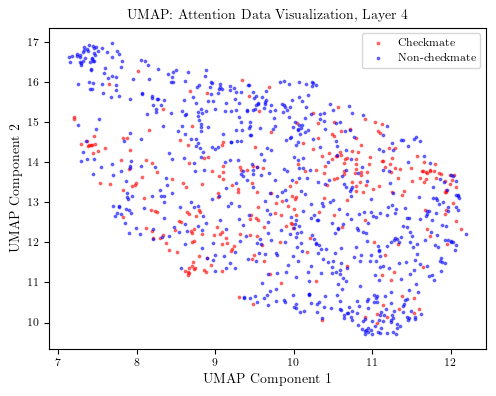

UMAP result shape: (1000, 2)


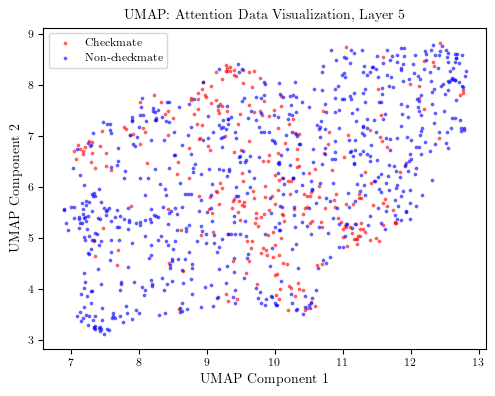

UMAP result shape: (1000, 2)


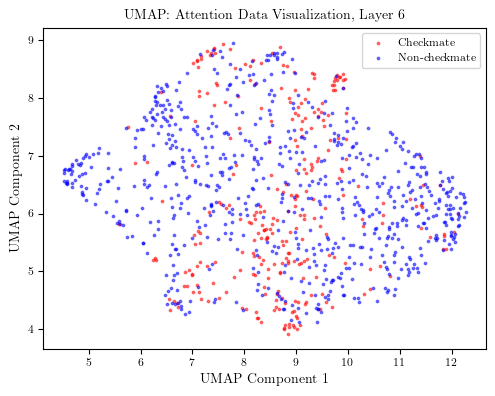

UMAP result shape: (1000, 2)


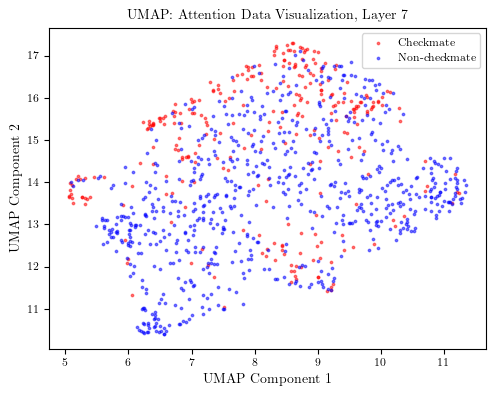

UMAP result shape: (1000, 2)


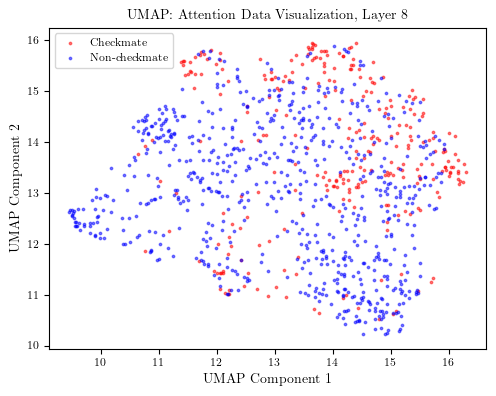

UMAP result shape: (1000, 2)


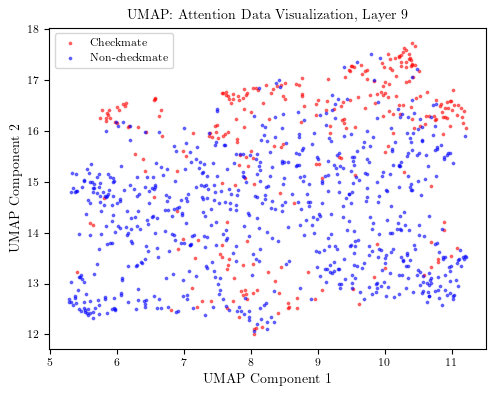

UMAP result shape: (1000, 2)


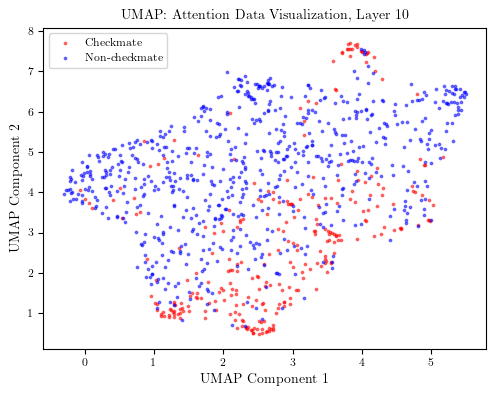

UMAP result shape: (1000, 2)


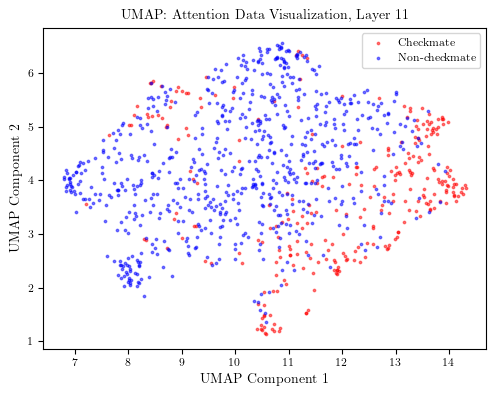

UMAP result shape: (1000, 2)


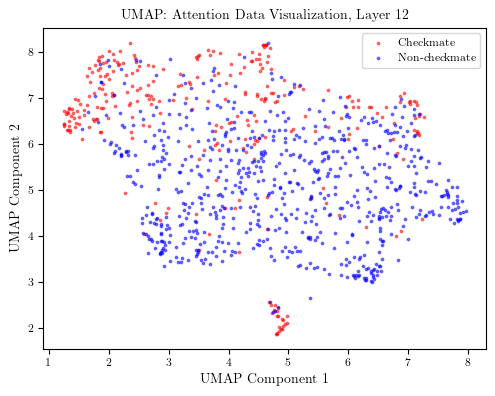

UMAP result shape: (1000, 2)


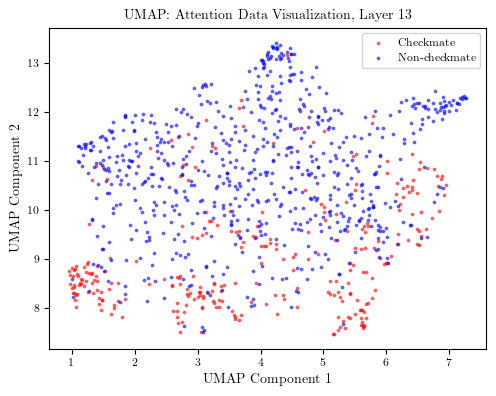

UMAP result shape: (1000, 2)


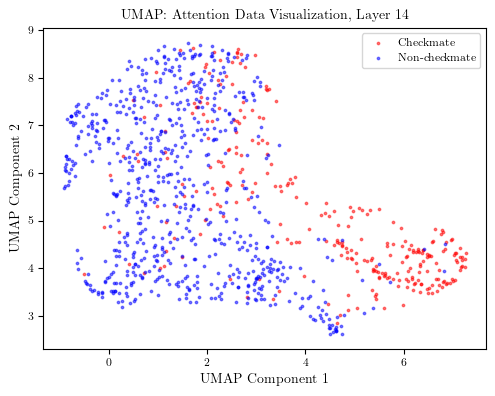

In [58]:
from umap import UMAP

for i in range(15):

    # Reshape the tensor to 2D
    attentions_2d = act_values[i].reshape(len(boards), -1)

    # Convert to numpy array
    attentions_np = attentions_2d.cpu().numpy()

    # Apply UMAP
    umap = UMAP(n_components=2)
    umap_result = umap.fit_transform(attentions_np)

    # Print the shape of the UMAP result
    print("UMAP result shape:", umap_result.shape)

    # Create a mask for checkmate puzzles
    checkmate_mask = study.puzzles.iloc[:len(boards)]["Themes"].apply(lambda x: "mateIn2" in x).values

    # Plot UMAP results
    fig, ax = plt.subplots(figsize=(5, 4))
    scatter_checkmate = ax.scatter(umap_result[checkmate_mask, 0], umap_result[checkmate_mask, 1], 
                                alpha=0.5, c='red', label='Checkmate', s=3)
    scatter_non_checkmate = ax.scatter(umap_result[~checkmate_mask, 0], umap_result[~checkmate_mask, 1], 
                                    alpha=0.5, c='blue', label='Non-checkmate', s=3)

    ax.set_xlabel('UMAP Component 1')
    ax.set_ylabel('UMAP Component 2')
    ax.set_title(f'UMAP: Attention Data Visualization, Layer {i}')
    ax.legend()

    plt.tight_layout()
    plt.show()

In [3]:
study = CheckmateStudy(load_all=False)


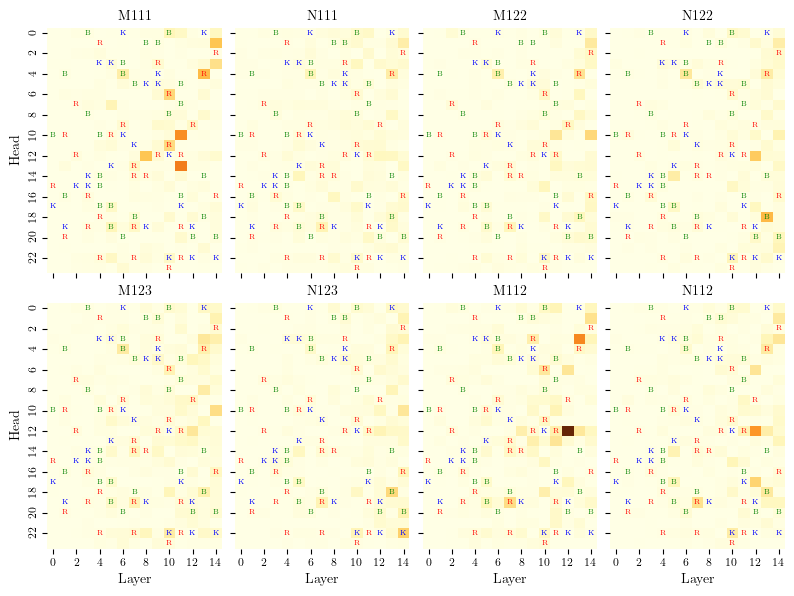

<Figure size 640x480 with 0 Axes>

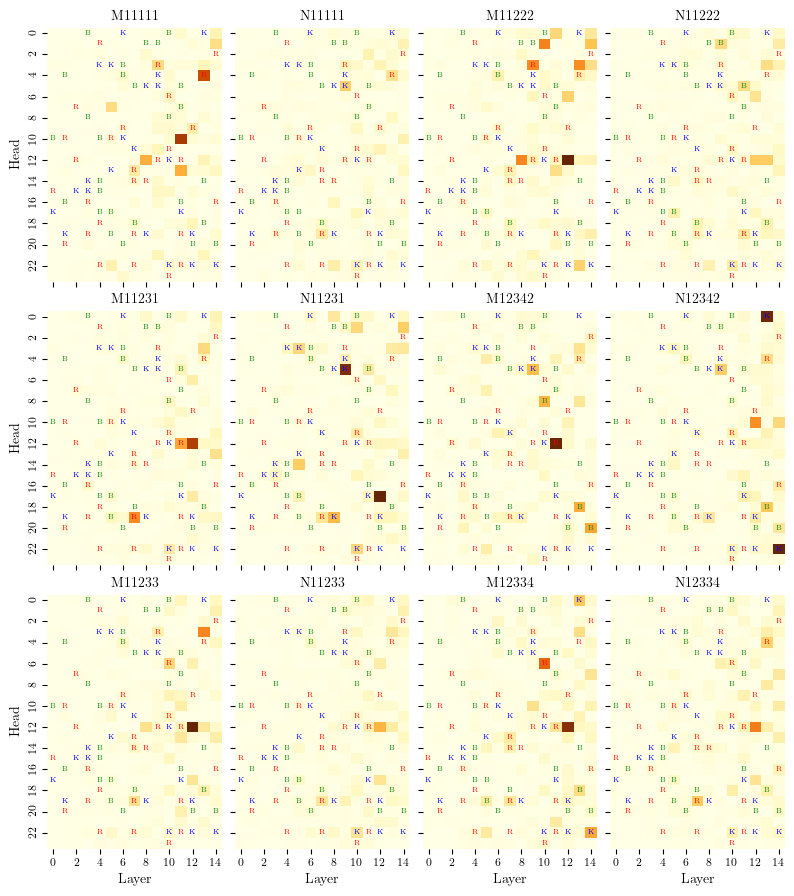

<Figure size 640x480 with 0 Axes>

In [5]:
possibilities = study.get_possibility_list('n', lengths=[3])
study.plot_attention_grid('n', possibilities, n_cols=2, vmax=0.73, filename="attention_grid_3_checkmate")
possibilities = study.get_possibility_list('n', lengths=[5])[:6]
study.plot_attention_grid('n', possibilities, n_cols=2, vmax=0.73, filename="attention_grid_5_checkmate")

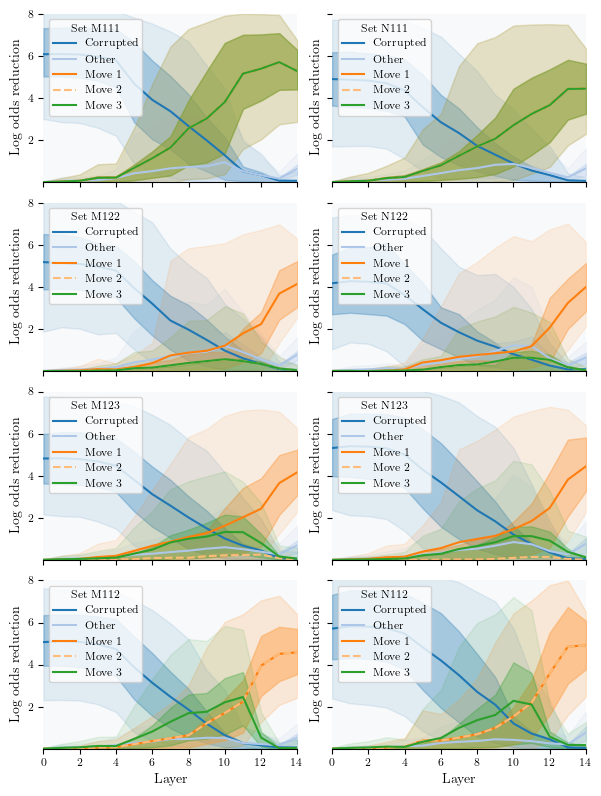

<Figure size 640x480 with 0 Axes>

In [6]:
possibilities = study.get_possibility_list('n', lengths=[3])
study.plot_residual_effects_grid('n', possibilities, n_cols=1, filename="residual_effects_3_checkmate")

/home/dcruz/Pivotal/leela-interp/src/leela_interp/core/checkmate_study.py:113: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left", title=f"Set {'M' if mate else 'N'}{row_col[2]}")
/home/dcruz/Pivotal/leela-interp/src/leela_interp/core/checkmate_study.py:113: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left", title=f"Set {'M' if mate else 'N'}{row_col[2]}")
/home/dcruz/Pivotal/leela-interp/src/leela_interp/core/checkmate_study.py:113: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left", title=f"Set {'M' if mate else 'N'}{row_col[2]}")


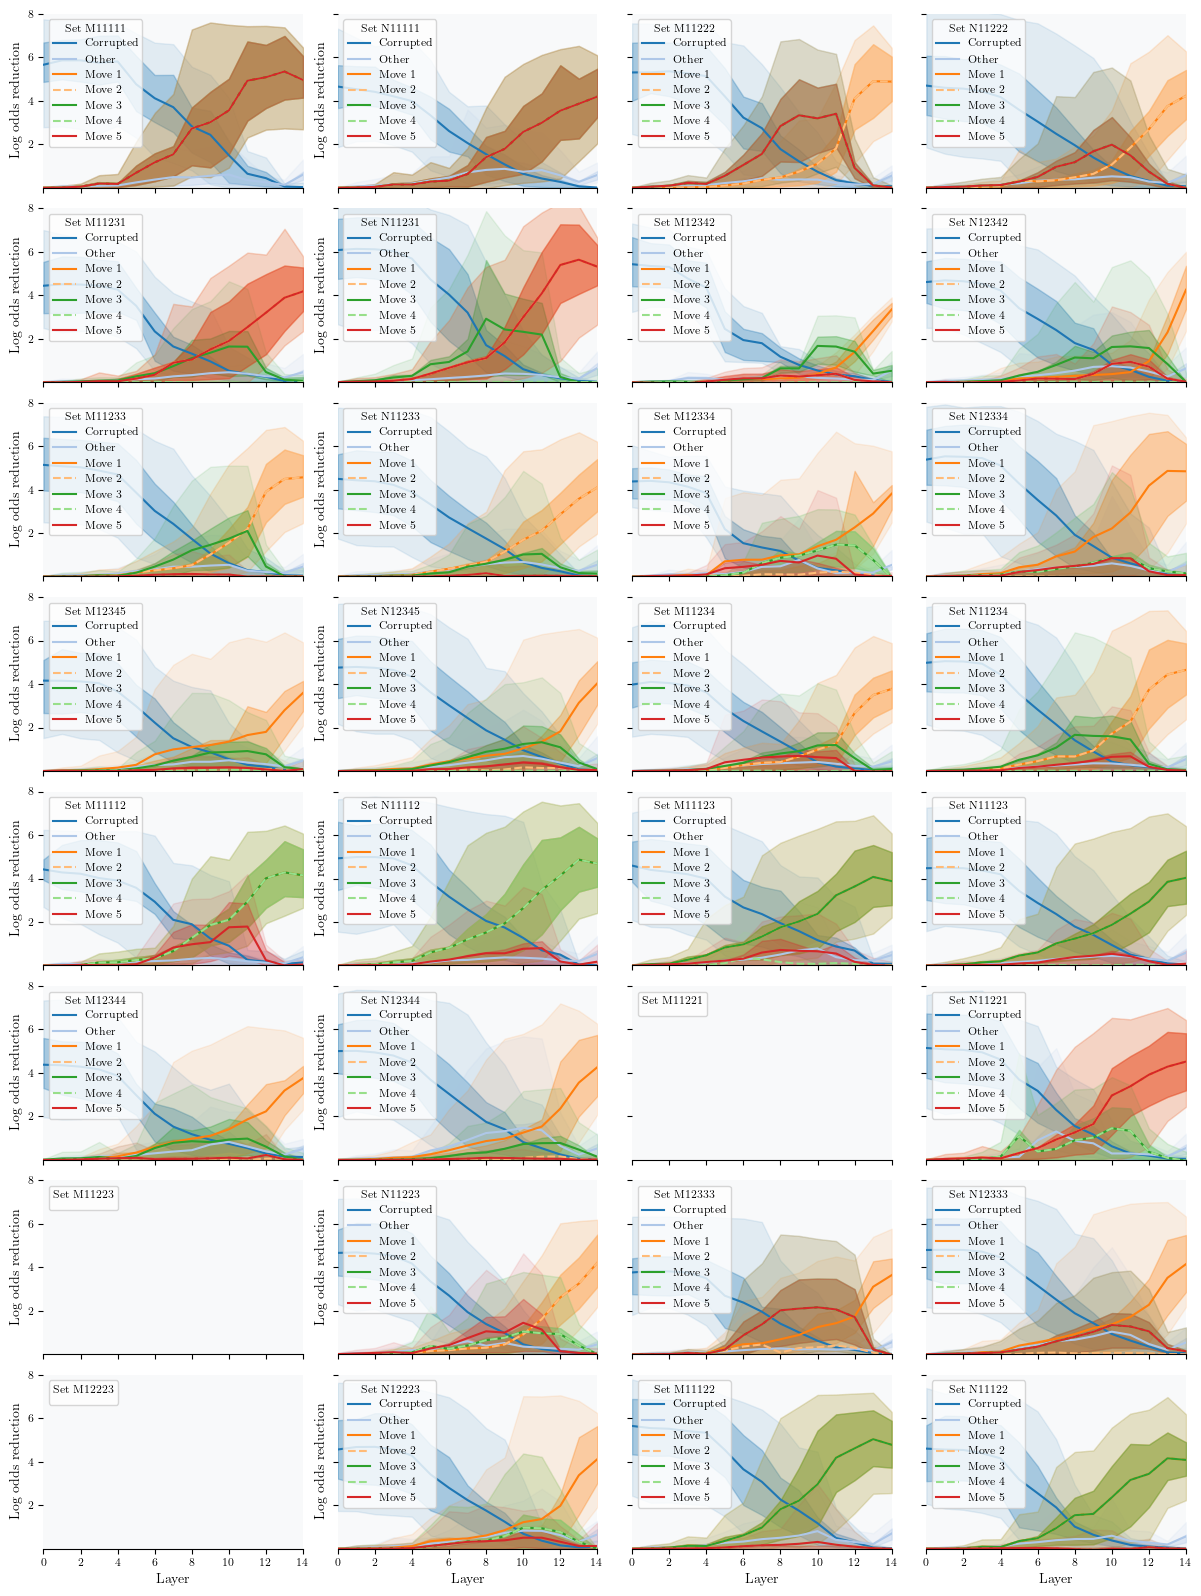

<Figure size 640x480 with 0 Axes>

In [74]:
possibilities = study.get_possibility_list('n', lengths=[5])
study.plot_residual_effects_grid('n', possibilities, n_cols=2, filename="residual_effects_5_checkmate")

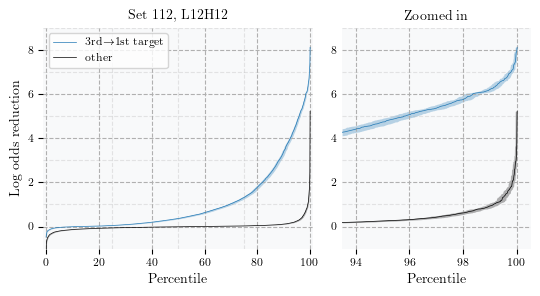

In [79]:
case, puzzle_set = ('L12H12', "112")
tag = ''
filename = None
ablation_study = AblationStudy(folder_name=case + ("_" + tag if tag != '' else "") + "_" + puzzle_set)
ablation_study.plot_ablation_effects(filename=None if filename is None else filename + "_" + case + ("_" + tag if tag != '' else "")+ "_" + puzzle_set, puzzle_set=puzzle_set, LH=case)

In [83]:
ablation_study.ablation['other']

torch.Size([7394])

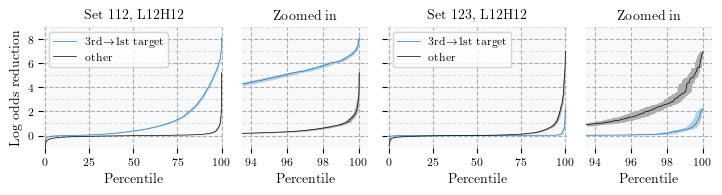

In [75]:
ablation_study = AblationStudy(folder_name="")
ablation_configs = [
    ('L12H12', "112"),
    ('L12H12', "123")
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=2, filename="paper_ablation_effects_3")

In [77]:
ablation_study.ablations

AttributeError: 'AblationStudy' object has no attribute 'ablations'

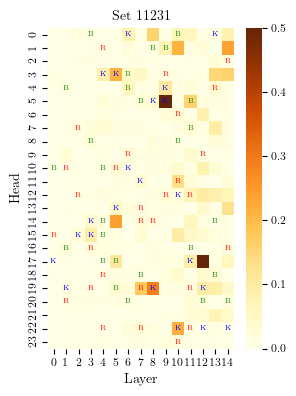

In [47]:
study = DoubleAttentionStudy(load_all=False)
possibility = '11231'
study.plot_attention('n', possibility)

In [20]:
double_effects = -study.double_attention_sets['n'][possibility]['2'].cpu().numpy()
effects = -study.attention_sets['n'][possibility][:16].cpu().numpy()
mean_double_effects = double_effects.mean(axis=0)
mean_effects = effects.mean(axis=0)

In [21]:
# Get indices of highest entries in decreasing order
top_indices = np.argsort(mean_double_effects.flatten())[::-1]

# Print the top 10 indices and their corresponding values
print("Top 10 indices and values:")
for i, idx in enumerate(top_indices[:20]):
    indices = np.unravel_index(idx, mean_double_effects.shape)
    #print(indices)
    layer_inds = [layer for j, layer in enumerate(indices) if j%2 == 0]
    head_inds = [head for j, head in enumerate(indices) if j%2 == 1]
    layers = [layer_inds[0]] + [layer + layer_inds[0] for layer in layer_inds[1:]]
    heads = head_inds
    #print(layers, heads)
    single_effects = np.sum([effects[:, layers[i], heads[i]] for i in range(len(layers))], axis=0)
    extra = np.mean(double_effects[:, *indices] - single_effects, axis=0)
    print(f"{i+1}. Index: ({layers}, {heads}), Value: {mean_double_effects[*indices]:.4f}, Extra: {extra:.4f} ({[effects[:, layers[i], heads[i]].mean() for i in range(len(layers))]})")

Top 10 indices and values:
1. Index: ([12, 13], [12, 3]), Value: 1.2021, Extra: 0.0283 ([0.8619289, 0.31192338])
2. Index: ([12, 13], [12, 1]), Value: 1.0414, Extra: 0.0000 ([0.8619289, 0.17941803])
3. Index: ([11, 12], [12, 12]), Value: 1.0164, Extra: 0.0098 ([0.14460148, 0.8619289])
4. Index: ([12, 13], [12, 12]), Value: 1.0121, Extra: 0.0307 ([0.8619289, 0.11950272])
5. Index: ([11, 12], [0, 12]), Value: 0.9900, Extra: -0.0008 ([0.12896466, 0.8619289])
6. Index: ([12, 13], [12, 19]), Value: 0.9510, Extra: -0.0228 ([0.8619289, 0.111867666])
7. Index: ([12, 13], [12, 13]), Value: 0.9409, Extra: 0.0427 ([0.8619289, 0.03623239])
8. Index: ([12, 13], [12, 18]), Value: 0.9402, Extra: -0.0056 ([0.8619289, 0.08394693])
9. Index: ([12, 12], [12, 17]), Value: 0.9377, Extra: 0.0196 ([0.8619289, 0.05616547])
10. Index: ([11, 12], [19, 12]), Value: 0.9274, Extra: 0.0294 ([0.036152415, 0.8619289])
11. Index: ([12, 13], [12, 22]), Value: 0.9244, Extra: 0.0289 ([0.8619289, 0.033595666])
12. Index: 

In [22]:
from leela_interp.tools.attention import attention_attribution, top_k_attributions
from leela_interp.tools.patching import activation_patch

11
Board with highest double attention in L14H20:

Top 5 attention attributions:
{'d4g7': -0.0018955729901790619, 'c7b8': -0.0014082276029512286, 'd4g1': 0.0008989589405246079, 'd4f6': -0.0007215689984150231, 'd4e3': -0.0006922241882421076}


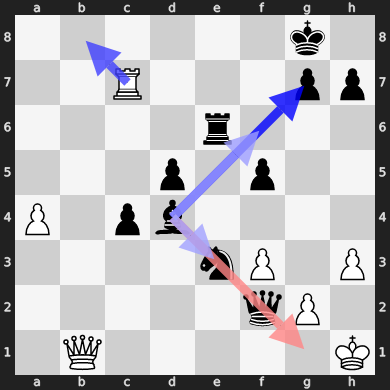

In [9]:
# Get entry with highest double attention in L14H20, from double attention set
# Get entry with highest double attention in L14H20, from double attention set
max_entry = np.argmax(double_effects[:, 5, 17, 0, 19])
print(max_entry)
good_puzzle = study.puzzle_sets['n'][possibility].iloc[max_entry]
good_board = LeelaBoard.from_puzzle(good_puzzle)

print("Board with highest double attention in L14H20:")
good_board.plot()

# Visualize attention patterns
attribution = attention_attribution(
    [good_board], layer=5, head=17, model=model, return_pt=True
)[0]
values, colors = top_k_attributions(attribution, good_board, k=5)
print("\nTop 5 attention attributions:")
print(values)
good_board.plot(arrows=colors, show_lastmove=False)    



Top 5 attention attributions:
{'g8f7': 0.0015825539594516158, 'f7g6': -0.0012480540899559855, 'f7g8': -0.0008403860265389085, 'e3f2': 0.0008272872655652463, 'b8c7': -0.0007743341848254204}


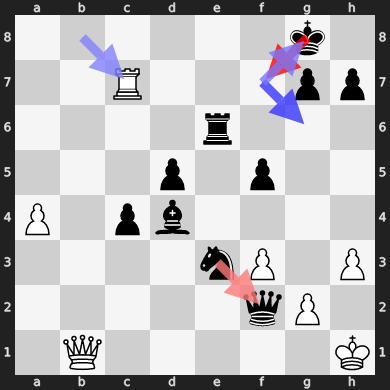

In [10]:
attribution = attention_attribution(
    [good_board], layer=5, head=19, model=model, return_pt=True
)[0]
values, colors = top_k_attributions(attribution, good_board, k=5)
print("\nTop 5 attention attributions:")
print(values)
good_board.plot(arrows=colors, show_lastmove=False)

In [11]:
good_puzzle.principal_variation

['b1b8', 'e6e8', 'b8e8']

In [56]:
mask_1 = study.puzzle_sets['n'][possibility]["Themes"].apply(lambda x: "mateIn3" in x)
mask_2 = ~mask_1
mask_1, mask_2 = mask_1.to_numpy(), mask_2.to_numpy()

In [57]:
sum(mask_1), sum(mask_2)

(25, 1335)

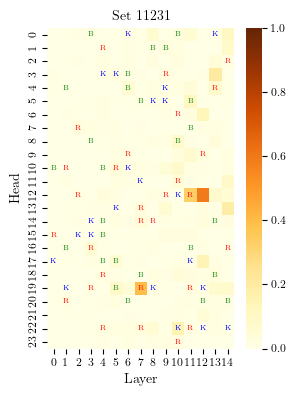

In [58]:
study.plot_attention('n', possibility, mask=mask_1, vmax=1.)

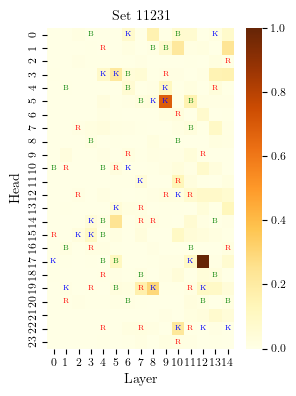

In [59]:
study.plot_attention('n', possibility, mask=mask_2, vmax=1.)

In [ ]:
attribution = attention_attribution(
    [good_board], layer=12, head=12, model=model, return_pt=True
)[0]
values, colors = top_k_attributions(attribution, good_board, k=5)
print(values)
good_board.plot(arrows=colors, show_lastmove=False)

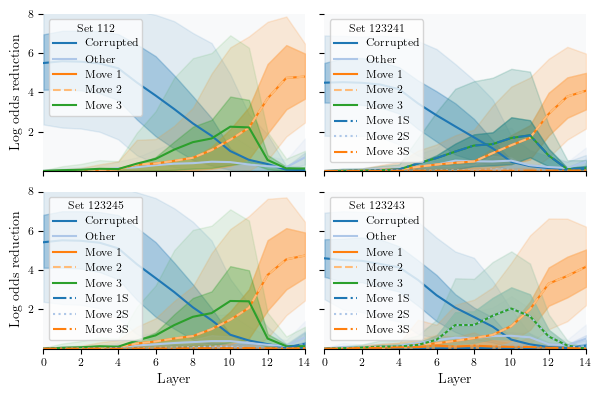

<Figure size 640x480 with 0 Axes>

In [5]:
possibilities = [('s', possibility) for possibility in study.get_possibility_list('s', lengths=[3]) if possibility[1] == possibility[3] != possibility[5]]
possibilities = [('n', '112')] + possibilities
study.plot_residual_effects_grid(possibilities, y_max=8, n_cols=2, filename="paper_residual_effects_3S_112")

## Attention heads

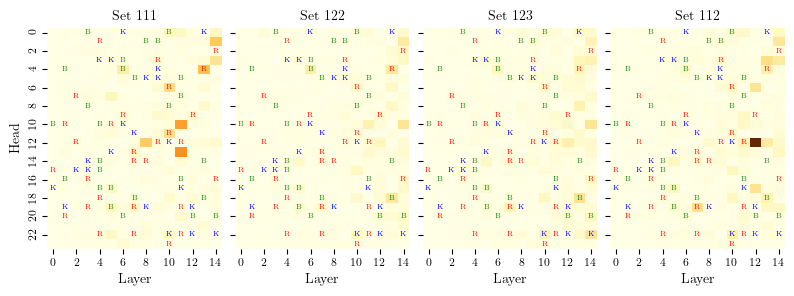

<Figure size 640x480 with 0 Axes>

In [7]:
possibilities = study.get_possibility_list('n', lengths=[3])
study.plot_attention_grid('n', possibilities, n_cols=4, vmax=0.73, filename="paper_attention_heads_3")

# L12H12

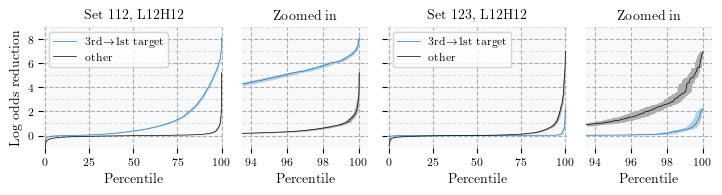

In [4]:
ablation_study = AblationStudy(folder_name="")
ablation_configs = [
    ('L12H12', "112"),
    ('L12H12', "123")
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=2, filename="paper_ablation_effects_3")

In [5]:
from leela_interp.core.ablation_study import AblationCheckmateStudy

/home/dcruz/Pivotal/leela-interp/src/leela_interp/core/general_study.py:88: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.effect_sets[tag][possibility] = torch.load(f)


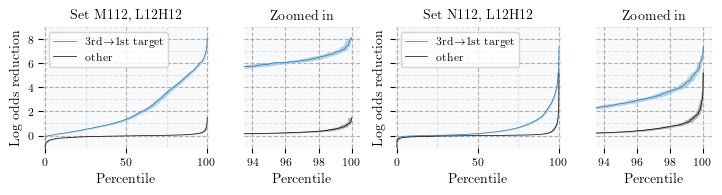

In [3]:
ablation_study = AblationCheckmateStudy(folder_name="")
ablation_configs = [
    ('L12H12', "112"),
    ('L12H12', "123")
]
ablation_configs = [
    ('L12H12', "112"),
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=1, filename="paper_ablation_effects_3_checkmate")

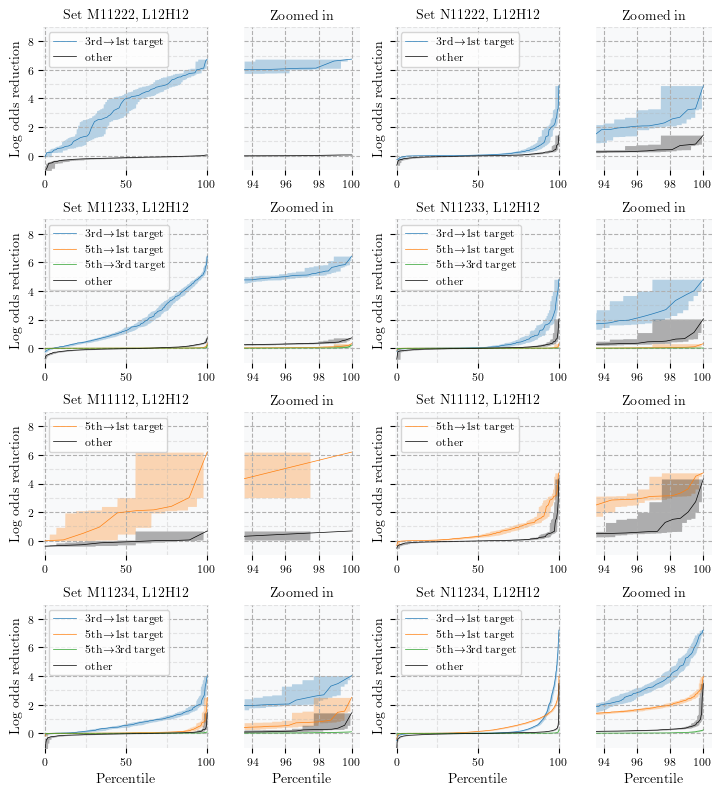

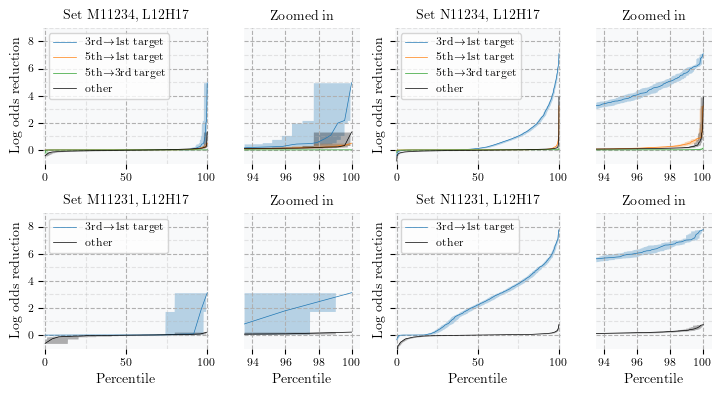

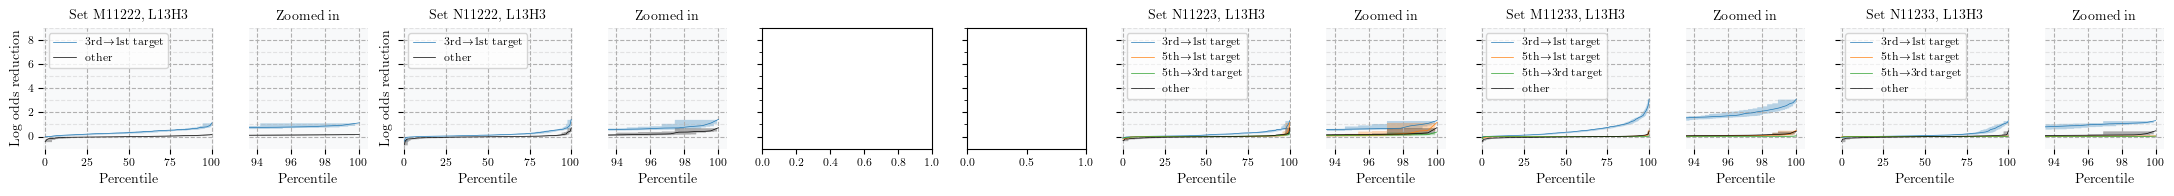

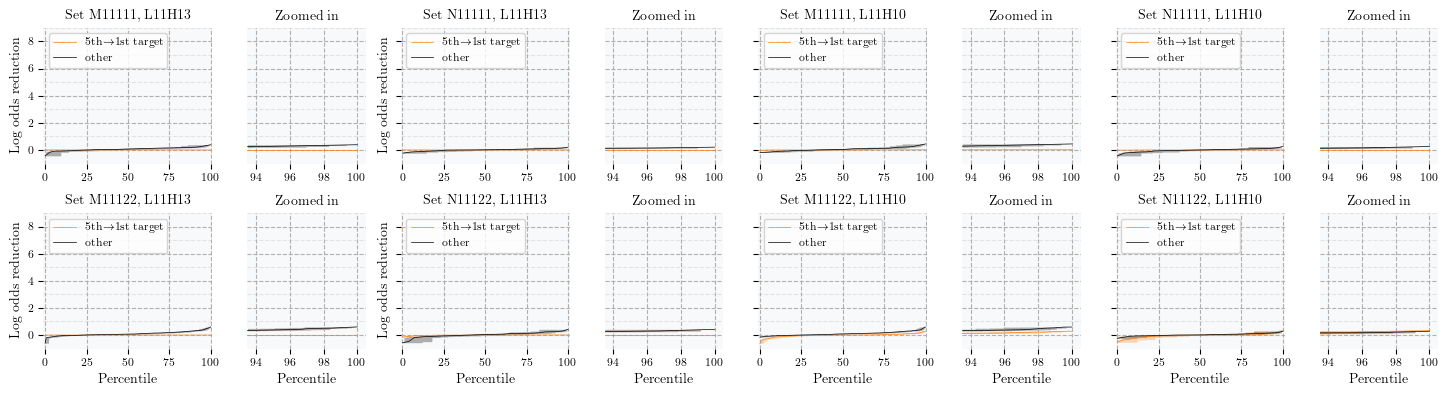

In [7]:
ablation_study = AblationCheckmateStudy(folder_name="")
ablation_configs = [
    ('L12H12', "11222"),
    ('L12H12', "11233"),
    ('L12H12', "11112"),
    ('L12H12', "11234"),
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=1, filename="paper_ablation_effects_5_L12H12_checkmate", tag='n')
ablation_configs = [
    ('L12H17', "11234"),
    ('L12H17', "11231"),
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=1, filename="paper_ablation_effects_5_L12H17_checkmate", tag='n')
ablation_configs = [
    ('L13H3', "11222"),
    ('L13H3', "11223"),
    ('L13H3', "11233")
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=3, filename="paper_ablation_effects_5_L13H3_checkmate", tag='n')
ablation_configs = [
    ('L11H13', "11111"),
    ('L11H10', "11111"),
    ('L11H13', "11122"),
    ('L11H10', "11122")
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=2, filename="paper_ablation_effects_5_remaining_checkmate", tag='n')
# ablation_configs = [
#     ('L12H12', "11222"),
#     ('L13H3', "11222"),
#     ('L12H12', "11223"),
#     ('L13H3', "11223"),
#     ('L12H12', "11233"),
#     ('L13H3', "11233"),
#     ('L12H12', "11112"),
#     ('L12H12', "12334"),
#     ('L12H12', "11234"),
#     ('L12H17', "11234"),
#     ('L12H17', "11231"),
#     ('L12H17', "11221"),
#     ('L11H13', "11111"),
#     ('L11H10', "11111"),
#     ('L11H13', "11122"),
#     ('L11H10', "11122"),
#     ('L12H12', "12223"),
#     ('L12H12', "12344")
# ]
# ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=3, filename="paper_ablation_effects_5", tag='n')

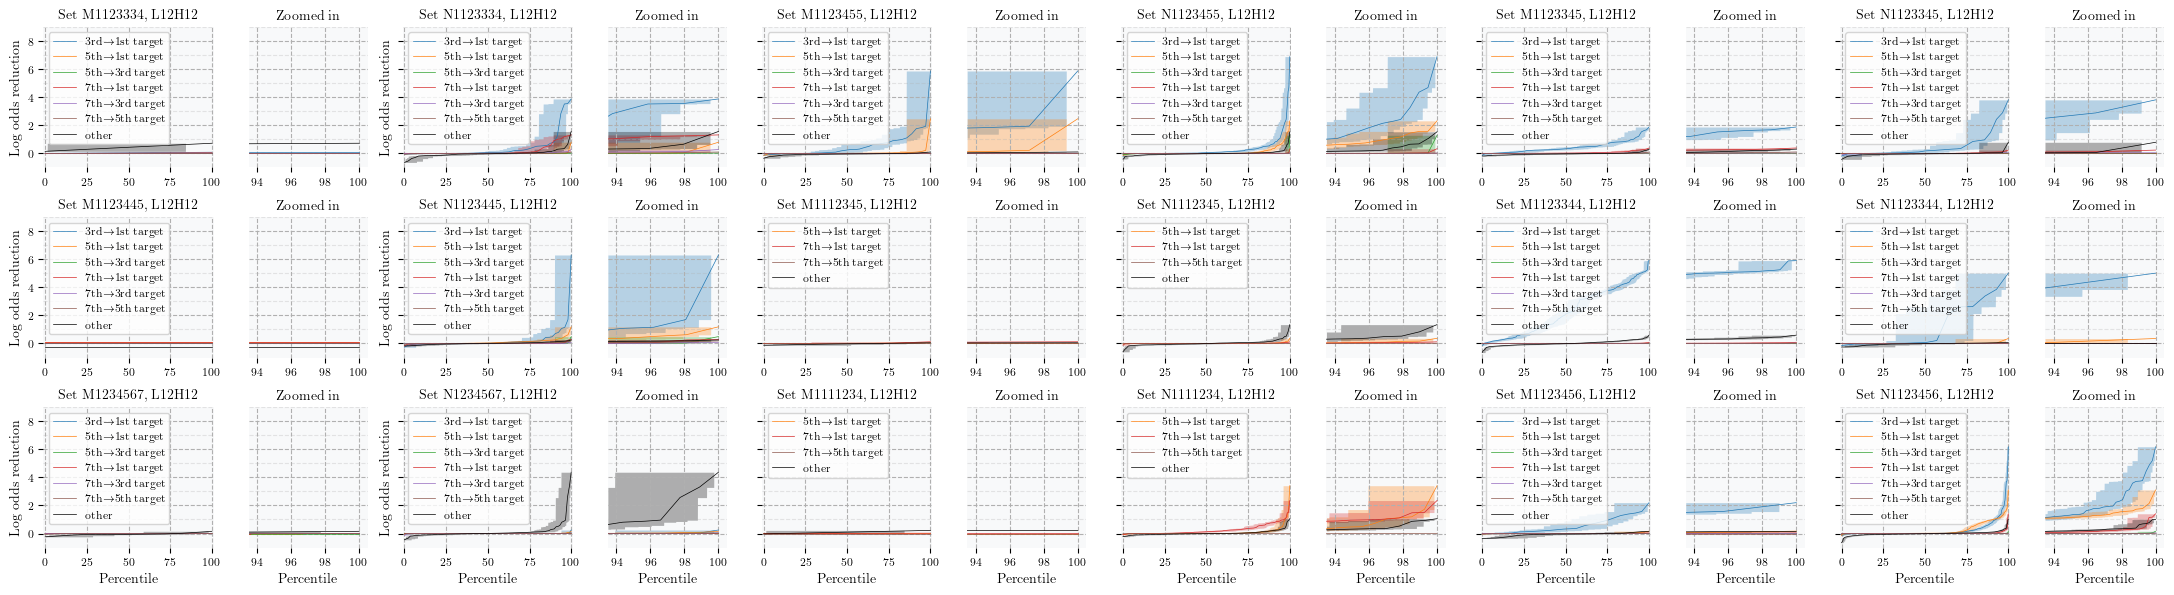

In [14]:
ablation_study = AblationCheckmateStudy(folder_name="", puzzlename="pv7")
ablation_configs = [
    ('L12H12', "1123334"),
    ('L12H12', "1123455"),
    ('L12H12', "1123345"),
    ('L12H12', "1123445"),
    ('L12H12', "1112345"),
    ('L12H12', "1123344"),
    ('L12H12', "1234567"),
    ('L12H12', "1111234"),
    ('L12H12', "1123456")
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=3, filename="paper_ablation_effects_7_L12H12_checkmate", tag='pv7_n')

# Fifth move analysis

## Residual stream

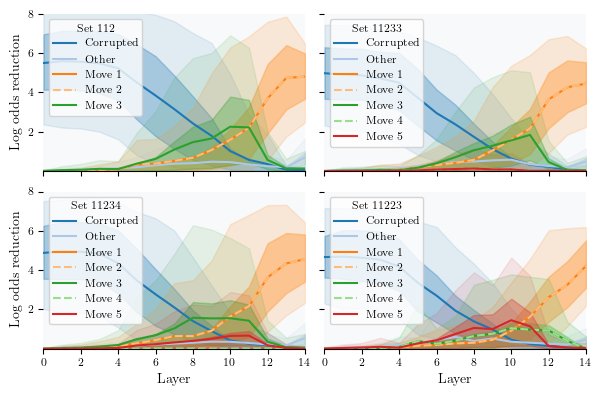

<Figure size 640x480 with 0 Axes>

In [24]:
study = FifthMoveStudy(load_all=False)
possibilities = [possibility for possibility in study.get_possibility_list('n', lengths=[5]) if len(set([possibility[0], possibility[2], possibility[4]])) == 3 and possibility[:3] == '112']
possibilities = ['112'] + possibilities
study.plot_residual_effects_grid('n', possibilities, y_max=8, n_cols=2, filename="paper_residual_effects_5_112")

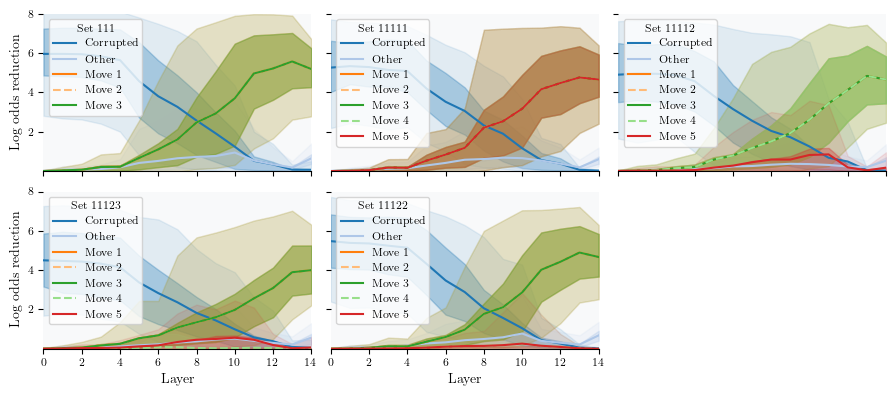

<Figure size 640x480 with 0 Axes>

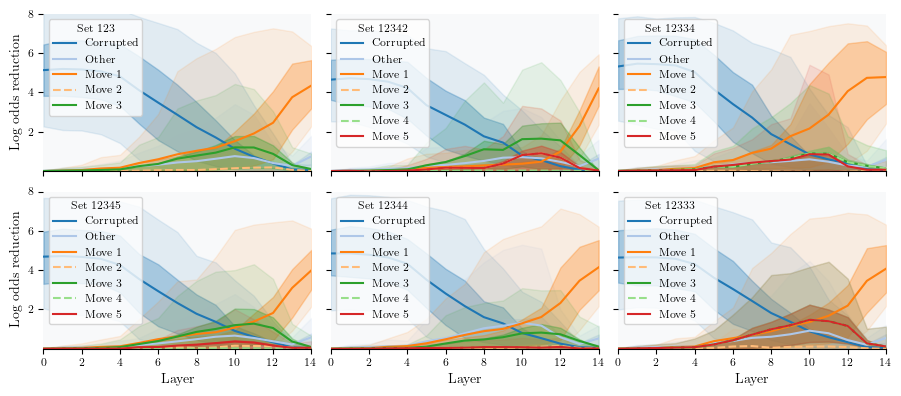

<Figure size 640x480 with 0 Axes>

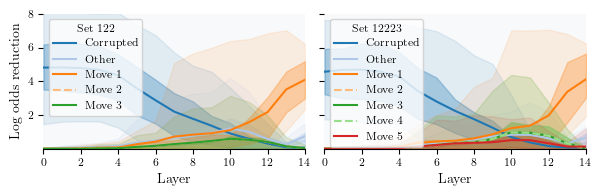

<Figure size 640x480 with 0 Axes>

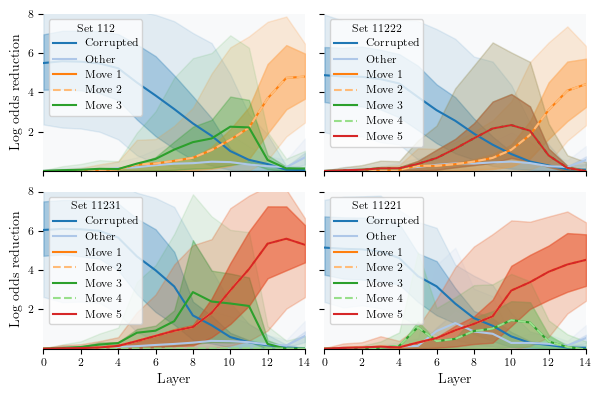

<Figure size 640x480 with 0 Axes>

In [6]:
possibilities = [possibility for possibility in study.get_possibility_list('n', lengths=[5]) if possibility[:3] == '111']
possibilities = ['111'] + possibilities
study.plot_residual_effects_grid('n', possibilities, y_max=8, n_cols=3, filename="paper_residual_effects_5_111")
possibilities = [possibility for possibility in study.get_possibility_list('n', lengths=[5]) if possibility[:3] == '123']
possibilities = ['123'] + possibilities
study.plot_residual_effects_grid('n', possibilities, y_max=8, n_cols=3, filename="paper_residual_effects_5_123")
possibilities = [possibility for possibility in study.get_possibility_list('n', lengths=[5]) if possibility[:3] == '122']
possibilities = ['122'] + possibilities
study.plot_residual_effects_grid('n', possibilities, y_max=8, n_cols=2, filename="paper_residual_effects_5_122")
possibilities = [possibility for possibility in study.get_possibility_list('n', lengths=[5]) if len(set([possibility[0], possibility[2], possibility[4]])) != 3 and possibility[:3] == '112']
possibilities = ['112'] + possibilities
study.plot_residual_effects_grid('n', possibilities, y_max=8, n_cols=2, filename="paper_residual_effects_5_112R")

## Attention heads

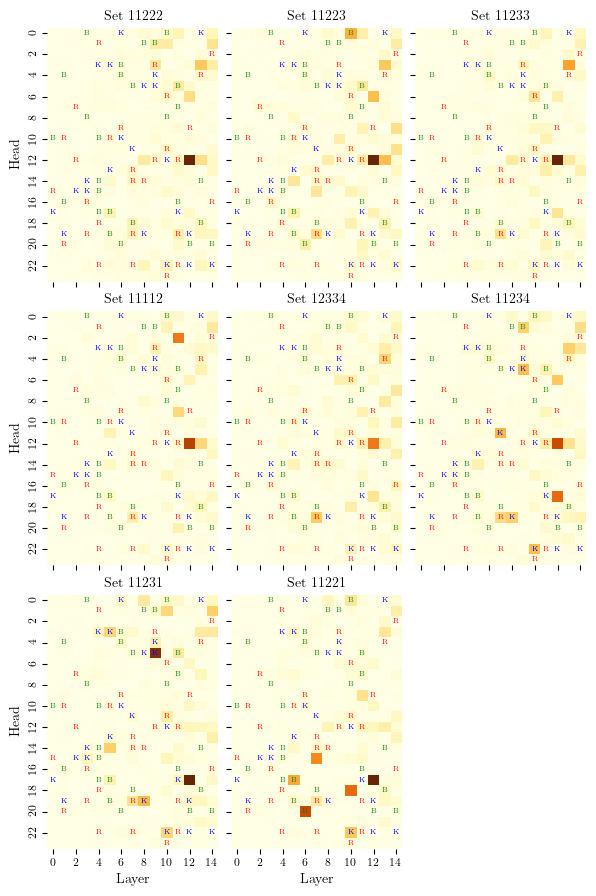

<Figure size 640x480 with 0 Axes>

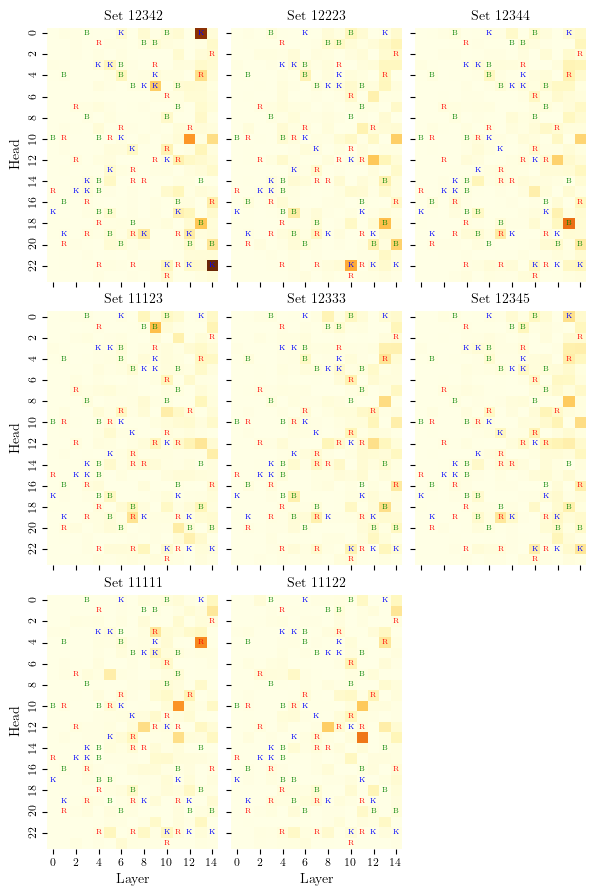

<Figure size 640x480 with 0 Axes>

In [8]:
#possibilities = study.get_possibility_list('n', lengths=[5])
# Ordering by hand
possibilities = ['11222', '11223', '11233'] #L12H12, L13H3
possibilities += ['11112', '12334'] #L12H12
possibilities += ['11234'] #L12H12, L12H17
possibilities += ['11231', '11221'] #L12H17
study.plot_attention_grid('n', possibilities, n_cols=3, vmax=0.73, filename="paper_attention_heads_5A")
possibilities = ['12342', '12223', '12344'] #random
possibilities += ['11123', '12333', '12345'] #low
possibilities += ['11111', '11122'] #L11H13, L11H10
study.plot_attention_grid('n', possibilities, n_cols=3, vmax=0.73, filename="paper_attention_heads_5B")

# L12H12, L12H17, L11H10, L11H13, L13H3

In [11]:
# ablation_configs = [
#     ('L12H12', "11222"),
#     ('L13H3', "11222"),
#     ('L12H12', "11223"),
#     ('L13H3', "11223"),
#     ('L12H12', "11233"),
#     ('L13H3', "11233"),
#     ('L12H12', "11112"),
#     ('L12H12', "12334"),
#     ('L12H12', "11234"),
#     ('L12H17', "11234"),
#     ('L12H17', "11231"),
#     ('L12H17', "11221"),
#     ('L11H13', "11111"),
#     ('L11H10', "11111"),
#     ('L11H13', "11122"),
#     ('L11H10', "11122"),
#     ('L12H12', "12223"),
#     ('L12H12', "12344")
# ]

ablation_configs = [
    ('L13H3', "11222"),
]

for config in ablation_configs:
    layer_head, puzzle = config
    layer = layer_head[1:3]  # Extract layer number
    head = layer_head[4:]    # Extract head number
    
    command = f"python3 scripts/run_single_head.py --filename interesting_puzzles_n_{puzzle} --layer {layer} --head {head} --device cuda --main"
    
    print(f"Running command: {command}")
    subprocess.run(command, shell=True)
    print("Command completed.\n")

Running command: python3 scripts/run_single_head.py --filename interesting_puzzles_n_11222 --layer 13 --head 3 --device cuda --main
Using device: cuda


100%|██████████| 3/3 [00:00<00:00,  4.40it/s]


Command completed.



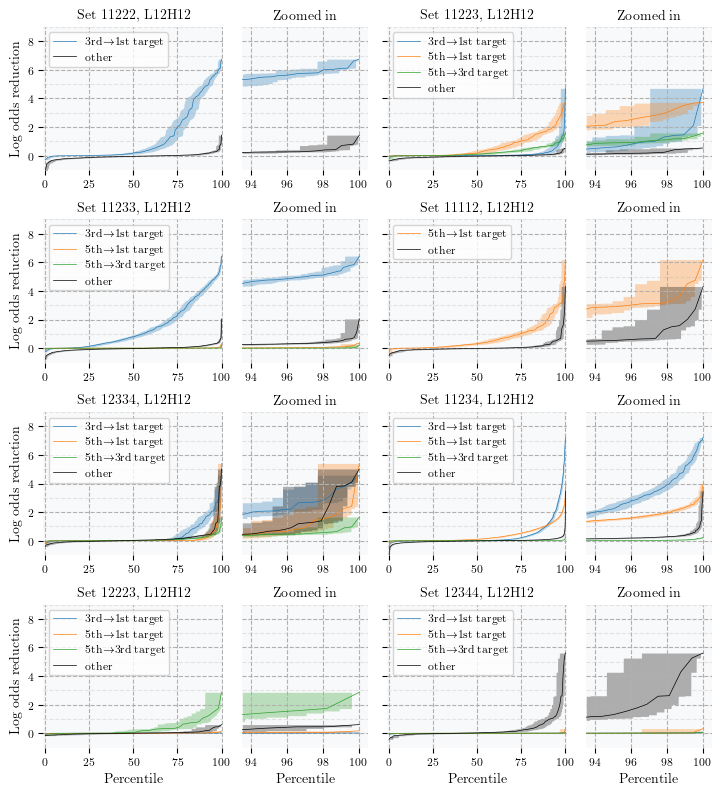

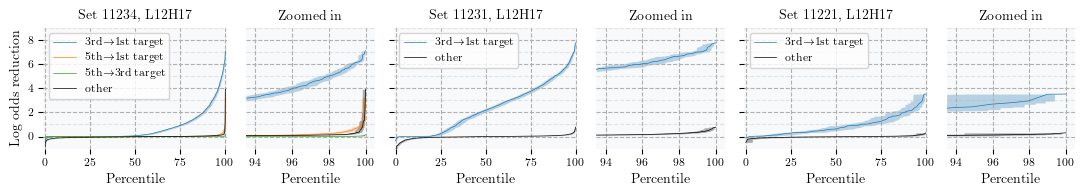

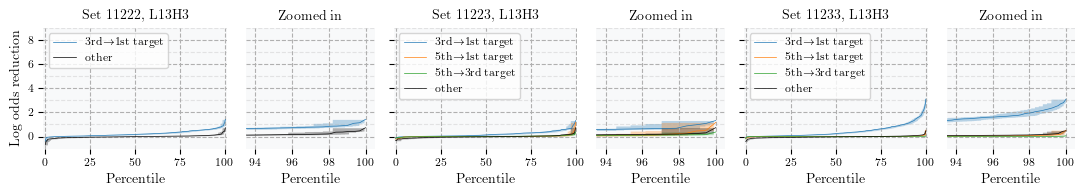

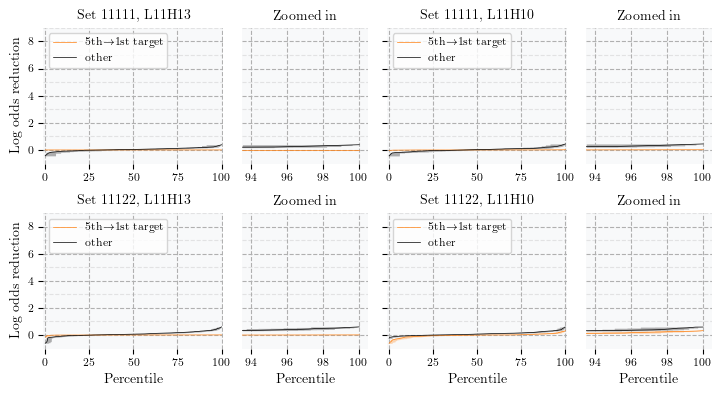

In [9]:
ablation_study = AblationStudy(folder_name="")
ablation_configs = [
    ('L12H12', "11222"),
    ('L12H12', "11223"),
    ('L12H12', "11233"),
    ('L12H12', "11112"),
    ('L12H12', "12334"),
    ('L12H12', "11234"),
    ('L12H12', "12223"),
    ('L12H12', "12344")
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=2, filename="paper_ablation_effects_5_L12H12", tag='n')
ablation_configs = [
    ('L12H17', "11234"),
    ('L12H17', "11231"),
    ('L12H17', "11221")
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=3, filename="paper_ablation_effects_5_L12H17", tag='n')
ablation_configs = [
    ('L13H3', "11222"),
    ('L13H3', "11223"),
    ('L13H3', "11233")
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=3, filename="paper_ablation_effects_5_L13H3", tag='n')
ablation_configs = [
    ('L11H13', "11111"),
    ('L11H10', "11111"),
    ('L11H13', "11122"),
    ('L11H10', "11122")
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=2, filename="paper_ablation_effects_5_remaining", tag='n')
# ablation_configs = [
#     ('L12H12', "11222"),
#     ('L13H3', "11222"),
#     ('L12H12', "11223"),
#     ('L13H3', "11223"),
#     ('L12H12', "11233"),
#     ('L13H3', "11233"),
#     ('L12H12', "11112"),
#     ('L12H12', "12334"),
#     ('L12H12', "11234"),
#     ('L12H17', "11234"),
#     ('L12H17', "11231"),
#     ('L12H17', "11221"),
#     ('L11H13', "11111"),
#     ('L11H10', "11111"),
#     ('L11H13', "11122"),
#     ('L11H10', "11122"),
#     ('L12H12', "12223"),
#     ('L12H12', "12344")
# ]
# ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=3, filename="paper_ablation_effects_5", tag='n')

## Probing

In [31]:
possibility = '12345'

command = f"python3 scripts/probing.py --filename interesting_puzzles_n_{possibility} --main --random_model --n_seeds 5 --max_goal_square 5 --min_goal_square 1 --add_opponent"

print(f"Running command: {command}")
subprocess.run(command, shell=True)
print("Command completed.\n")

Running command: python3 scripts/probing.py --filename interesting_puzzles_n_12345 --main --random_model --n_seeds 5 --max_goal_square 5 --min_goal_square 1 --add_opponent
common_str: n
Using 430 puzzles total, 301 for training.
Using device: cuda


100%|██████████| 15/15 [00:00<00:00, 25.18it/s]


Using device: cuda


100%|██████████| 15/15 [00:00<00:00, 25.14it/s]


Command completed.



185


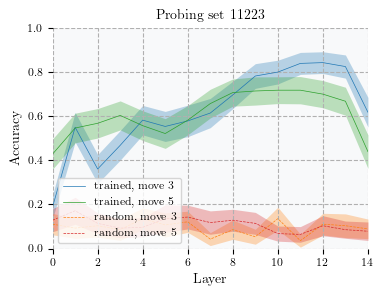

In [34]:
cases = ['11223']
for case in cases:
    probing_study = ProbingStudy(case_number=case, tag_name='n')#, add_opponent=True, start_goal_square=1)
    print(probing_study.n_examples)
    probing_study.plot_probe_results(filename="paper_probe_results_" + case)

# 7th move analysis

## Residual stream

In [38]:
study = FifthMoveStudy(puzzlename="pv7", load_all=False)

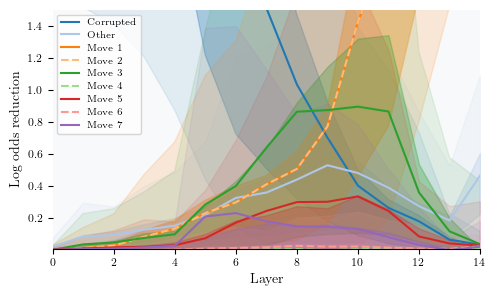

In [42]:
study.plot_residual_effects('n', '1123456', filename="paper_residual_effects_7_1123456", y_max=1.5)

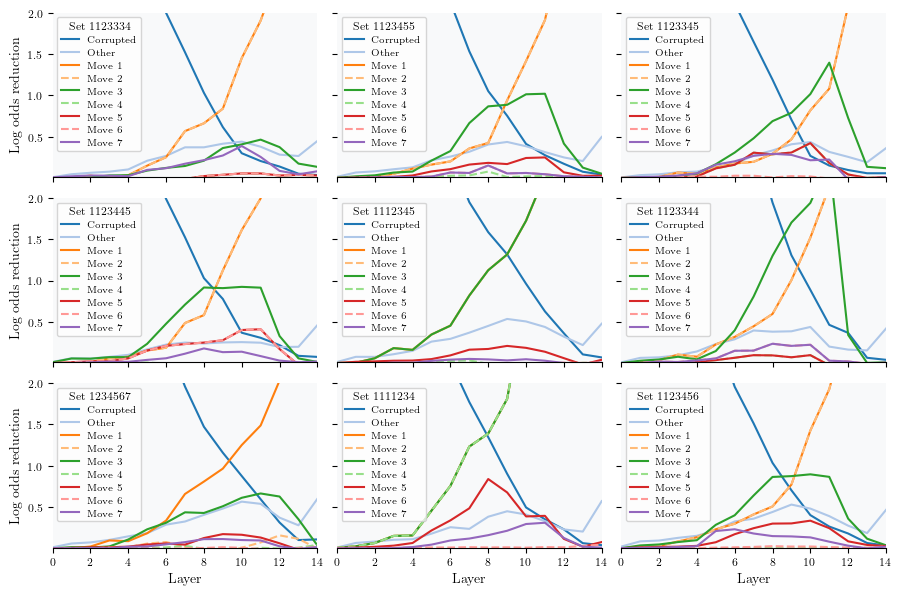

<Figure size 640x480 with 0 Axes>

In [36]:
possibilities = study.get_possibility_list('n', lengths=[7])
study.plot_residual_effects_grid('n', possibilities, n_cols=3, filename="paper_residual_effects_7", y_max=2, plot_ci=False)

## Attention heads

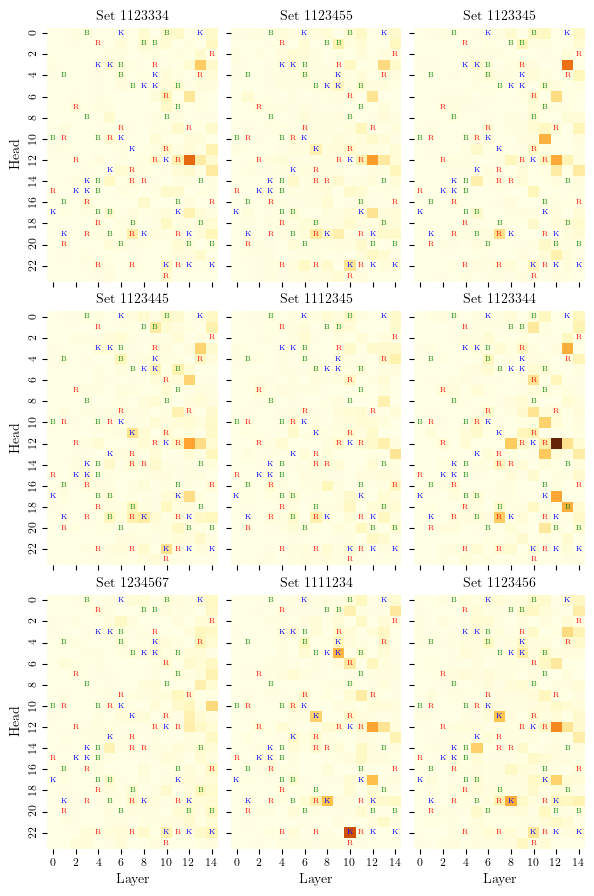

<Figure size 640x480 with 0 Axes>

In [14]:
possibilities = study.get_possibility_list('n', lengths=[7])
study.plot_attention_grid('n', possibilities, n_cols=3, filename="paper_attention_heads_7", vmax=0.73)

In [17]:
[(possibility, len(study.puzzle_sets['n'][possibility])) for possibility in possibilities]

[('1123334', 51),
 ('1123455', 224),
 ('1123345', 94),
 ('1123445', 54),
 ('1112345', 101),
 ('1123344', 223),
 ('1234567', 100),
 ('1111234', 137),
 ('1123456', 541)]

In [24]:
# import subprocess

# ablation_configs = [
#     ('L12H12', "1112345"),
#     ('L12H12', "1111234"),
# ]

# for config in ablation_configs:
#     layer_head, puzzle = config
#     layer = layer_head[1:3]  # Extract layer number
#     head = layer_head[4:]    # Extract head number
    
#     command = f"python3 scripts/run_single_head.py --filename interesting_puzzles_pv7_n_{puzzle} --layer {layer} --head {head} --device cuda --main"
    
#     print(f"Running command: {command}")
#     subprocess.run(command, shell=True)
#     print("Command completed.\n")

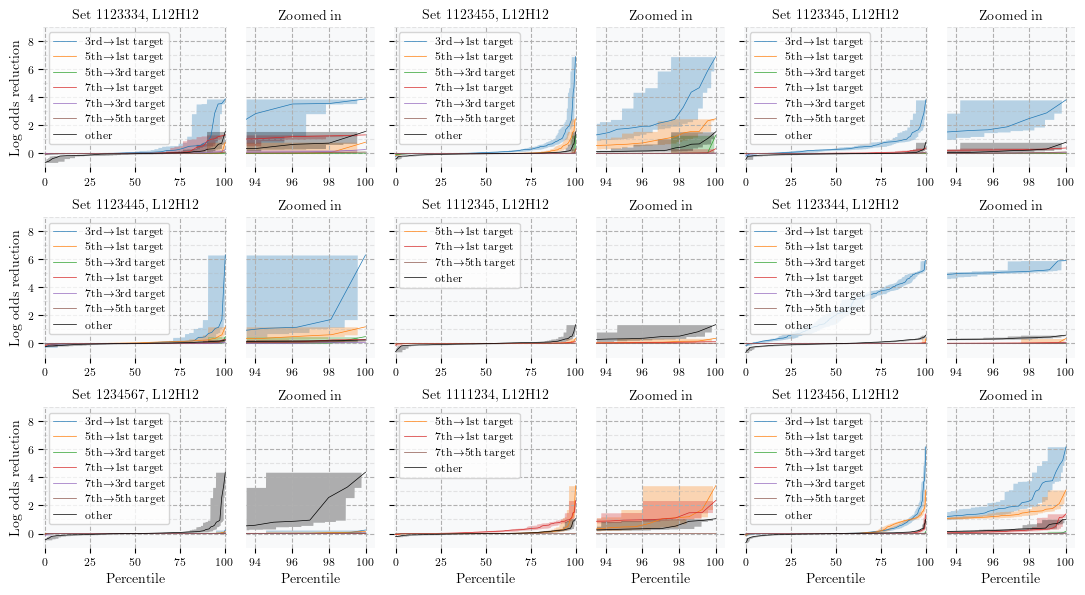

In [15]:
ablation_study = AblationStudy(folder_name="")
ablation_configs = [
    ('L12H12', "1123334"),
    ('L12H12', "1123455"),
    ('L12H12', "1123345"),
    ('L12H12', "1123445"),
    ('L12H12', "1112345"),
    ('L12H12', "1123344"),
    ('L12H12', "1234567"),
    ('L12H12', "1111234"),
    ('L12H12', "1123456")
]
ablation_study.plot_ablation_effects_grid(ablation_configs, n_cols=3, filename="paper_ablation_effects_7_L12H12", tag='pv7_n')

## Probing

In [ ]:
for possibility in possibilities:

    command = f"python3 scripts/probing.py --filename interesting_puzzles_pv7_n_{possibility} --main --random_model --n_seeds 5 --max_goal_square 7"
    
    print(f"Running command: {command}")
    subprocess.run(command, shell=True)
    print("Command completed.\n")

51


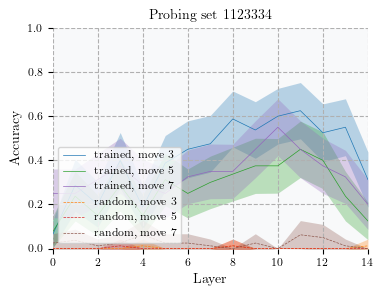

224


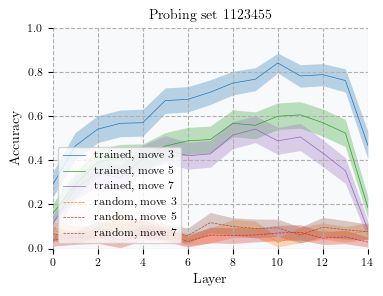

94


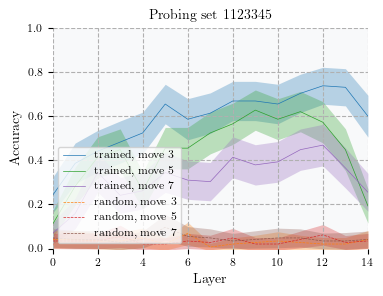

54


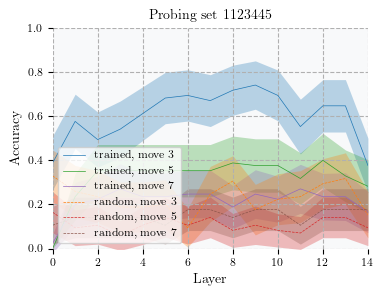

101


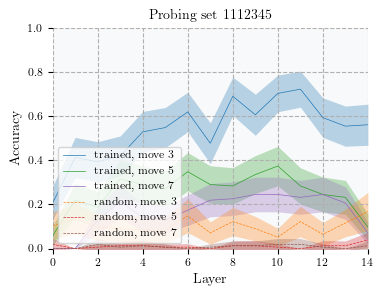

223


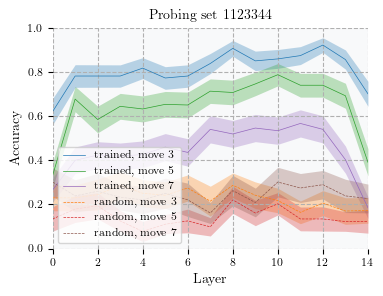

100


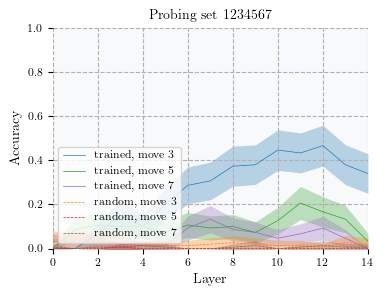

137


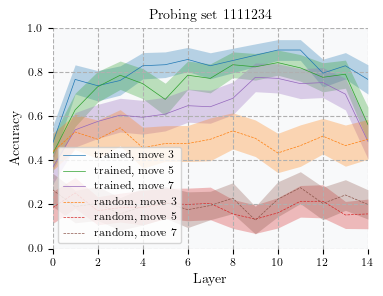

541


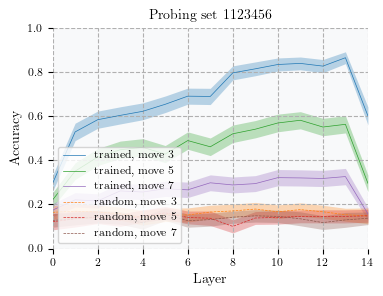

In [37]:
cases = possibilities

for case in cases:
    probing_study = ProbingStudy(case_number=case, tag_name='pv7_n')
    print(probing_study.n_examples)
    probing_study.plot_probe_results(filename="paper_probe_results_" + case)

# Double branches

In [21]:
from leela_interp.core.double_branch import DoubleBranchStudy

In [22]:
study = DoubleBranchStudy(puzzlename="nomate2", load_all=True)

123425 4 4


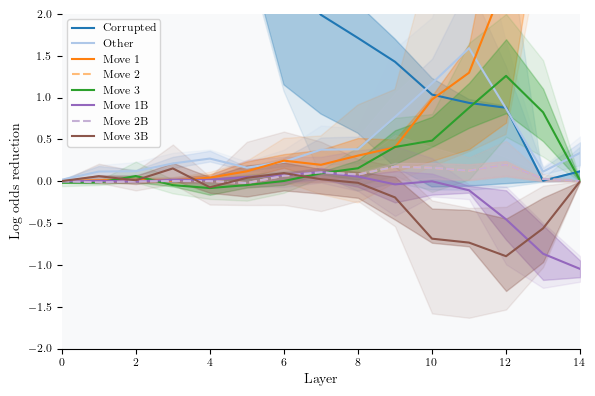

In [23]:
study.plot_residual_effects('b', '123425', filename="paper_residual_effects_123425")